In [1]:
!pip -q install lightgbm xgboost catboost openpyxl joblib

In [3]:
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score,
    confusion_matrix,
)

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

DATA_DIR = "."
OUTPUT_DIR = "."
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [ ]:
file_name_h1 = os.path.join(DATA_DIR, "ATM_Featured_Dataset_JAN24_JUN24.csv")
file_name_h2 = os.path.join(DATA_DIR, "ATM_Featured_Dataset_JUL24_DEC24.csv")

for fp in (file_name_h1, file_name_h2):
    if not os.path.exists(fp):
        raise FileNotFoundError(
            f"Could not find {fp}. Update DATA_DIR in the previous cell "
            f"or place the CSV in this notebook's working directory."
        )

print("Found file:", file_name_h1)
print("Found file:", file_name_h2)

In [ ]:
df_h1 = pd.read_csv(file_name_h1)
df_h2 = pd.read_csv(file_name_h2)

print("Jan\u2013Jun 2024 shape:", df_h1.shape)
print("Jul\u2013Dec 2024 shape:", df_h2.shape)

# Both halves must share the same columns before it's safe to concatenate them
cols_h1, cols_h2 = set(df_h1.columns), set(df_h2.columns)
if cols_h1 != cols_h2:
    raise ValueError(
        "Column mismatch between the two files.\n"
        f"Only in Jan-Jun: {cols_h1 - cols_h2}\n"
        f"Only in Jul-Dec: {cols_h2 - cols_h1}"
    )

df = pd.concat([df_h1, df_h2], ignore_index=True)
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

rows_before_dedup = len(df)
df = (
    df.drop_duplicates(subset=["ATMID", "Date"], keep="first")
      .sort_values(["ATMID", "Date"])
      .reset_index(drop=True)
)
rows_after_dedup = len(df)

print("\nCombined shape (before dedup):", (rows_before_dedup, df.shape[1]))
print("Combined shape (after dedup): ", df.shape)
if rows_before_dedup != rows_after_dedup:
    print(f"WARNING: removed {rows_before_dedup - rows_after_dedup} overlapping ATM/Date "
          f"row(s) found in both files (kept the Jan\u2013Jun version).")
else:
    print("No overlapping ATM/Date rows between the two files \u2014 clean full-year join.")

print("\nCombined date range:", df["Date"].min().date(), "to", df["Date"].max().date())
display(df.head())

In [7]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nColumn names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

print("\nData types:")
display(df.dtypes.to_frame("Data Type"))

Rows: 21930
Columns: 43

Column names:
1. ATMID
2. Date
3. Daily_Withdrawal
4. Transaction_Count
5. Average_Transaction
6. Median_Transaction
7. Maximum_Transaction
8. Minimum_Transaction
9. Withdrawal_Std
10. Day
11. Month
12. Year
13. DayOfWeek
14. WeekOfYear
15. Quarter
16. IsWeekend
17. IsMonthStart
18. IsMonthEnd
19. Withdrawal_Lag_1
20. Withdrawal_Lag_2
21. Withdrawal_Lag_3
22. Withdrawal_Lag_7
23. Withdrawal_Lag_14
24. Withdrawal_Lag_21
25. Withdrawal_Lag_28
26. Rolling_Mean_3
27. Rolling_Mean_7
28. Rolling_Mean_14
29. Rolling_Mean_28
30. Rolling_Std_7
31. Rolling_Std_14
32. Rolling_Std_28
33. EWMA_7
34. EWMA_14
35. Demand_Change_1D
36. Demand_Change_7D
37. Demand_Growth_1D
38. Demand_Growth_7D
39. Short_Long_Demand_Ratio
40. Transaction_Intensity
41. Average_Transaction_Change
42. Weekday_Average_Demand
43. Target_Next_Day

Data types:


,Data Type
ATMID,object
Date,object
Daily_Withdrawal,float64
Transaction_Count,float64
Average_Transaction,float64
Median_Transaction,float64
Maximum_Transaction,float64
Minimum_Transaction,float64
Withdrawal_Std,float64
Day,int64


**Convert date and validate dataset**

In [8]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

if df["Date"].isna().any():
    print("WARNING: Invalid dates found:", df["Date"].isna().sum())
else:
    print("All dates converted successfully.")

print("\nDate range:")
print(df["Date"].min(), "to", df["Date"].max())

print("\nNumber of unique dates:")
print(df["Date"].nunique())

print("\nNumber of unique ATMs:")
print(df["ATMID"].nunique())

print("\nATM observations:")
display(df.groupby("ATMID").size().describe())

All dates converted successfully.

Date range:
2024-01-01 00:00:00 to 2024-03-26 00:00:00

Number of unique dates:
86

Number of unique ATMs:
255

ATM observations:


count    255.0
mean      86.0
std        0.0
min       86.0
25%       86.0
50%       86.0
75%       86.0
max       86.0
dtype: float64

In [9]:
date_count_per_atm = (
    df.groupby("ATMID")["Date"]
      .nunique()
)

print("Unique dates per ATM:")
display(date_count_per_atm.describe())

incomplete_atms = date_count_per_atm[
    date_count_per_atm != df["Date"].nunique()
]

if len(incomplete_atms) == 0:
    print("SUCCESS: Every ATM has observations for every available date.")
else:
    print("WARNING: Some ATMs have missing dates.")
    display(incomplete_atms)

Unique dates per ATM:


count    255.0
mean      86.0
std        0.0
min       86.0
25%       86.0
50%       86.0
75%       86.0
max       86.0
Name: Date, dtype: float64

SUCCESS: Every ATM has observations for every available date.


**Check duplicate ATM/date combinations**

In [10]:
duplicates = df.duplicated(
    subset=["ATMID", "Date"]
).sum()

print("Duplicate ATM-Date combinations:", duplicates)

if duplicates == 0:
    print("SUCCESS: No duplicate ATM-Date records.")
else:
    print("WARNING: Duplicate ATM-Date records detected.")

Duplicate ATM-Date combinations: 0
SUCCESS: No duplicate ATM-Date records.


In [11]:
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
)

missing_table = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": (missing / len(df)) * 100
})

display(
    missing_table[
        missing_table["Missing_Count"] > 0
    ]
)

,Missing_Count,Missing_Percentage
Rolling_Std_28,7140,32.558140
Short_Long_Demand_Ratio,7140,32.558140
Withdrawal_Lag_28,7140,32.558140
Rolling_Mean_28,7140,32.558140
Withdrawal_Lag_21,5355,24.418605
Rolling_Std_14,3570,16.279070
Withdrawal_Lag_14,3570,16.279070
Rolling_Mean_14,3570,16.279070
Rolling_Std_7,1785,8.139535
Demand_Change_7D,1785,8.139535


**Rebuild next day target**

In [12]:
df = (
    df.sort_values(["ATMID", "Date"])
      .reset_index(drop=True)
)

# Recalculate next-day withdrawal for each ATM
df["Target_Next_Day_Calculated"] = (
    df.groupby("ATMID")["Daily_Withdrawal"]
      .shift(-1)
)

# Compare existing target with calculated target
comparison_mask = (
    df["Target_Next_Day"].notna() &
    df["Target_Next_Day_Calculated"].notna()
)

target_difference = (
    df.loc[comparison_mask, "Target_Next_Day"]
    -
    df.loc[comparison_mask, "Target_Next_Day_Calculated"]
).abs()

print("Rows compared:", comparison_mask.sum())
print("Maximum target difference:", target_difference.max())
print("Mean target difference:", target_difference.mean())

if target_difference.max() == 0:
    print("\nSUCCESS: Existing target matches the calculated next-day demand.")
else:
    print("\nWARNING: Existing target contains differences.")

Rows compared: 21675
Maximum target difference: 0.0
Mean target difference: 0.0

SUCCESS: Existing target matches the calculated next-day demand.


In [13]:
df["Target_Next_Day"] = df["Target_Next_Day_Calculated"]

df.drop(
    columns=["Target_Next_Day_Calculated"],
    inplace=True
)

print("Target successfully reconstructed.")

Target successfully reconstructed.


**Remove rows without a real next-day target**

In [14]:
before_rows = len(df)

df = df.dropna(
    subset=["Target_Next_Day"]
).copy()

after_rows = len(df)

print("Rows before:", before_rows)
print("Rows after :", after_rows)
print("Rows removed:", before_rows - after_rows)

print("\nFinal forecasting date range:")
print(df["Date"].min(), "to", df["Date"].max())

Rows before: 21930
Rows after : 21675
Rows removed: 255

Final forecasting date range:
2024-01-01 00:00:00 to 2024-03-25 00:00:00


**Check target distribution**

Target statistics:


,Target_Next_Day
count,2.167500e+04
mean,4.784527e+05
std,3.809605e+05
min,0.000000e+00
25%,2.165000e+05
50%,3.985000e+05
75%,6.452500e+05
max,5.083500e+06


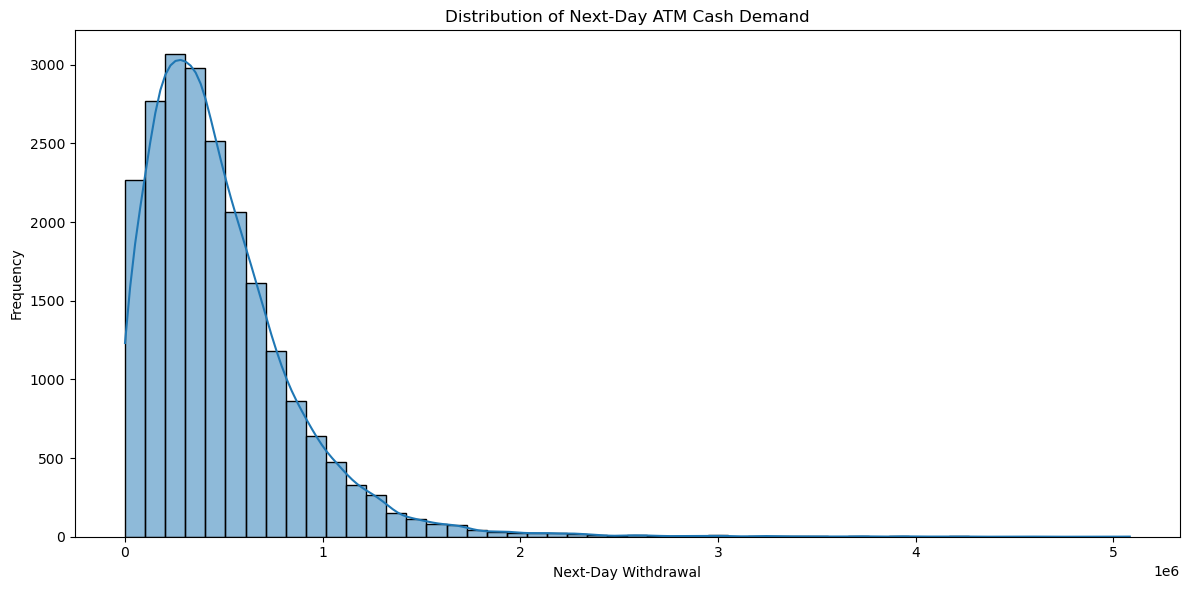

In [15]:
print("Target statistics:")

display(
    df["Target_Next_Day"]
      .describe()
      .to_frame()
)

plt.figure(figsize=(12, 6))

sns.histplot(
    df["Target_Next_Day"],
    bins=50,
    kde=True
)

plt.title("Distribution of Next-Day ATM Cash Demand")
plt.xlabel("Next-Day Withdrawal")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**Overall daily demand**

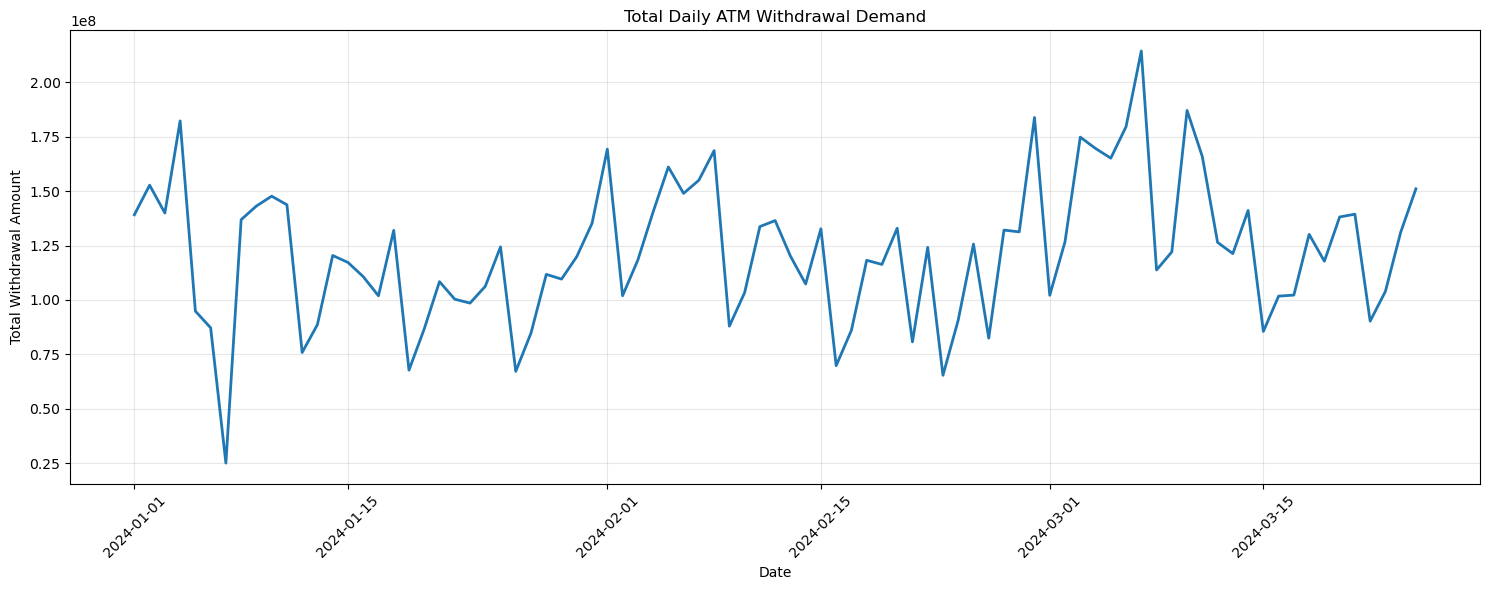

In [16]:
daily_demand = (
    df.groupby("Date")["Daily_Withdrawal"]
      .sum()
      .reset_index()
)

plt.figure(figsize=(15, 6))

plt.plot(
    daily_demand["Date"],
    daily_demand["Daily_Withdrawal"],
    linewidth=2
)

plt.title("Total Daily ATM Withdrawal Demand")
plt.xlabel("Date")
plt.ylabel("Total Withdrawal Amount")

plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

,DayOfWeek,Daily_Withdrawal,Day_Name
0,0,517693.363499,Sunday
1,1,512626.797386,Monday
2,2,504681.535948,Tuesday
3,3,606491.503268,Wednesday
4,4,334099.673203,Thursday
5,5,392275.163399,Friday
6,6,483252.614379,Saturday


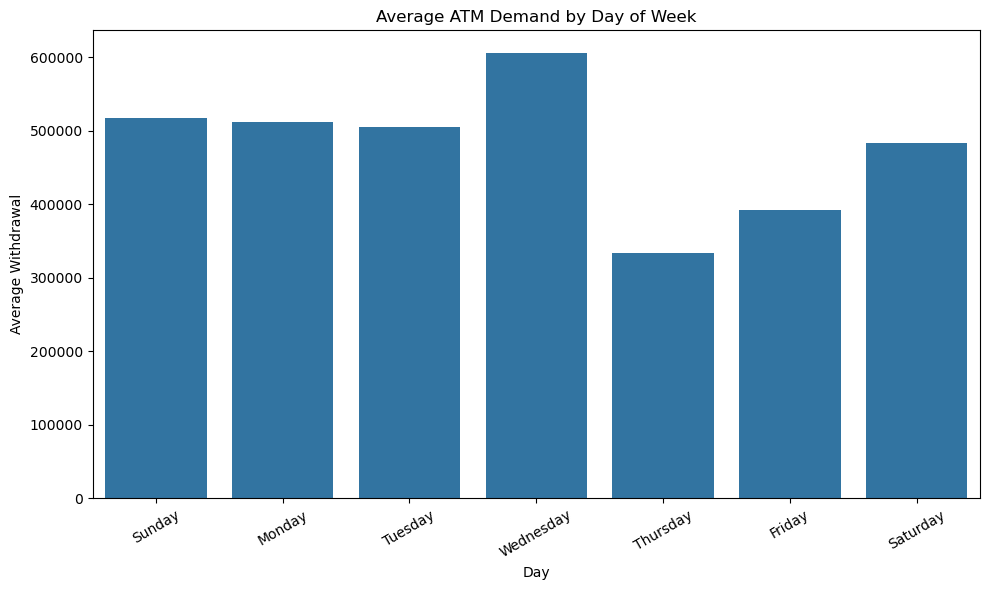

In [17]:
weekday_names = {
    0: "Sunday",
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday"
}

weekday_demand = (
    df.groupby("DayOfWeek")["Daily_Withdrawal"]
      .mean()
      .reset_index()
)

weekday_demand["Day_Name"] = (
    weekday_demand["DayOfWeek"]
    .map(weekday_names)
)

display(weekday_demand)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=weekday_demand,
    x="Day_Name",
    y="Daily_Withdrawal"
)

plt.title("Average ATM Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Withdrawal")

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

**ATM-level Demand**

In [18]:
atm_demand = (
    df.groupby("ATMID")["Daily_Withdrawal"]
      .agg(
          Total_Demand="sum",
          Average_Demand="mean",
          Maximum_Demand="max",
          Minimum_Demand="min"
      )
      .sort_values(
          "Average_Demand",
          ascending=False
      )
)

display(atm_demand.head(20))

,Total_Demand,Average_Demand,Maximum_Demand,Minimum_Demand
ATMID,,,,
ABBROK01,119831000.0,1.409776e+06,2541000.0,694500.0
ABBJIN01,114981500.0,1.352724e+06,4183500.0,21000.0
ABBJHE01,108309000.0,1.274224e+06,3490000.0,0.0
ABBIMM01,99627500.0,1.172088e+06,2953500.0,0.0
ABBMOH03,99624500.0,1.172053e+06,2152500.0,336000.0
ABBSIT01,99153500.0,1.166512e+06,2626000.0,89500.0
ABBUTR07,97662000.0,1.148965e+06,2399500.0,229000.0
ABBMDH01,94703000.0,1.114153e+06,3037000.0,0.0
ABBPRI01,84714000.0,9.966353e+05,3287500.0,0.0


In [19]:
feature_cols = [

    # Lag features
    "Withdrawal_Lag_1",
    "Withdrawal_Lag_2",
    "Withdrawal_Lag_3",
    "Withdrawal_Lag_7",
    "Withdrawal_Lag_14",
    "Withdrawal_Lag_21",
    "Withdrawal_Lag_28",

    # Rolling mean
    "Rolling_Mean_3",
    "Rolling_Mean_7",
    "Rolling_Mean_14",
    "Rolling_Mean_28",

    # Rolling volatility
    "Rolling_Std_7",
    "Rolling_Std_14",
    "Rolling_Std_28",

    # Exponential moving averages
    "EWMA_7",
    "EWMA_14",

    # Demand trend
    "Demand_Change_1D",
    "Demand_Change_7D",
    "Demand_Growth_1D",
    "Demand_Growth_7D",

    # Demand ratio
    "Short_Long_Demand_Ratio",

    # Transaction features
    "Transaction_Count",
    "Average_Transaction",
    "Median_Transaction",
    "Maximum_Transaction",
    "Minimum_Transaction",
    "Withdrawal_Std",

    # Calendar features
    "Day",
    "DayOfWeek",
    "Month",
    "Quarter",
    "WeekOfYear",
    "IsWeekend",
    "IsMonthStart",
    "IsMonthEnd",

    # Historical weekday behavior
    "Weekday_Average_Demand"
]

missing_features = [
    col for col in feature_cols
    if col not in df.columns
]

print("Number of selected features:", len(feature_cols))

if missing_features:
    print("\nMissing features:")
    print(missing_features)
else:
    print("SUCCESS: All selected features exist.")

Number of selected features: 36
SUCCESS: All selected features exist.


**Prepare Modeling Dataset**

In [20]:
model_df = df[
    ["ATMID", "Date"] +
    feature_cols +
    ["Target_Next_Day"]
].copy()

print("Before removing feature NaN values:")
print(model_df.shape)

model_df = model_df.dropna(
    subset=feature_cols + ["Target_Next_Day"]
).copy()

model_df = (
    model_df.sort_values(["Date", "ATMID"])
            .reset_index(drop=True)
)

print("\nAfter removing unusable rows:")
print(model_df.shape)

print(
    "\nRemaining missing values:",
    model_df[feature_cols + ["Target_Next_Day"]]
    .isna()
    .sum()
    .sum()
)

Before removing feature NaN values:
(21675, 39)

After removing unusable rows:
(14535, 39)

Remaining missing values: 0


**Modeling Data Range**

In [21]:
print("Modeling date range:")
print(
    model_df["Date"].min(),
    "→",
    model_df["Date"].max()
)

print(
    "\nNumber of dates:",
    model_df["Date"].nunique()
)

print(
    "Number of ATMs:",
    model_df["ATMID"].nunique()
)

print(
    "Rows:",
    len(model_df)
)

Modeling date range:
2024-01-29 00:00:00 → 2024-03-25 00:00:00

Number of dates: 57
Number of ATMs: 255
Rows: 14535


**CHRONOLOGICAL DATE-BASED SPLIT**

In [22]:
unique_dates = (
    model_df["Date"]
    .sort_values()
    .unique()
)

n_dates = len(unique_dates)

train_date_end = int(n_dates * 0.70)
validation_date_end = int(n_dates * 0.85)

train_dates = unique_dates[:train_date_end]
validation_dates = unique_dates[
    train_date_end:validation_date_end
]
test_dates = unique_dates[
    validation_date_end:
]

train = model_df[
    model_df["Date"].isin(train_dates)
].copy()

validation = model_df[
    model_df["Date"].isin(validation_dates)
].copy()

test = model_df[
    model_df["Date"].isin(test_dates)
].copy()

print("TRAIN")
print(train.shape)
print(train["Date"].min(), "→", train["Date"].max())

print("\nVALIDATION")
print(validation.shape)
print(validation["Date"].min(), "→", validation["Date"].max())

print("\nTEST")
print(test.shape)
print(test["Date"].min(), "→", test["Date"].max())

TRAIN
(9945, 39)
2024-01-29 00:00:00 → 2024-03-07 00:00:00

VALIDATION
(2295, 39)
2024-03-08 00:00:00 → 2024-03-16 00:00:00

TEST
(2295, 39)
2024-03-17 00:00:00 → 2024-03-25 00:00:00


**TRAIN-ONLY OUTLIER BOUNDS (LEAKAGE-SAFE)**


---


Bounds will be computed from the training split only, so no information from validation/test leaks into how outliers are defined.

In [23]:
# Compute per-ATM outlier bounds using ONLY the training split (no leakage)
train_target_stats = (
    train.groupby("ATMID")["Target_Next_Day"]
         .agg(Target_Q1=lambda x: x.quantile(0.25),
              Target_Q3=lambda x: x.quantile(0.75))
         .reset_index()
)

train_target_stats["IQR"] = train_target_stats["Target_Q3"] - train_target_stats["Target_Q1"]
train_target_stats["Upper_Bound"] = train_target_stats["Target_Q3"] + 1.5 * train_target_stats["IQR"]

# Fallback for ATMs with IQR == 0
global_upper_fallback = train["Target_Next_Day"].quantile(0.99)
train_target_stats["Upper_Bound"] = train_target_stats["Upper_Bound"].where(
    train_target_stats["IQR"] > 0, global_upper_fallback
)

display(train_target_stats.head(20))

,ATMID,Target_Q1,Target_Q3,IQR,Upper_Bound
0,ABBAGR01,541500.0,1044500.0,503000.0,1799000.0
1,ABBAGR02,246500.0,589750.0,343250.0,1104625.0
2,ABBAND01,233500.0,542750.0,309250.0,1006625.0
3,ABBASH01,138750.0,346000.0,207250.0,656875.0
4,ABBAST01,442500.0,835250.0,392750.0,1424375.0
5,ABBATI01,86750.0,190750.0,104000.0,346750.0
6,ABBBAD01,247250.0,547500.0,300250.0,997875.0
7,ABBBAD02,14500.0,89500.0,75000.0,202000.0
8,ABBBAD03,14500.0,121500.0,107000.0,282000.0
9,ABBBAN01,517500.0,874500.0,357000.0,1410000.0


**APPLY CAP TO TRAINING TARGET ONLY**


---


Validation and test keep the real, uncapped demand — only the training target is winsorized, so extreme spike-days can't dominate model training while evaluation still reflects true business error.

In [24]:
train = train.merge(train_target_stats[["ATMID", "Upper_Bound"]], on="ATMID", how="left")
validation = validation.merge(train_target_stats[["ATMID", "Upper_Bound"]], on="ATMID", how="left")
test = test.merge(train_target_stats[["ATMID", "Upper_Bound"]], on="ATMID", how="left")

train["Upper_Bound"] = train["Upper_Bound"].fillna(global_upper_fallback)
validation["Upper_Bound"] = validation["Upper_Bound"].fillna(global_upper_fallback)
test["Upper_Bound"] = test["Upper_Bound"].fillna(global_upper_fallback)

train["Target_Next_Day_Capped"] = train["Target_Next_Day"].clip(upper=train["Upper_Bound"])

affected = (train["Target_Next_Day_Capped"] < train["Target_Next_Day"]).sum()
print(f"Training rows capped: {affected} ({affected/len(train)*100:.2f}%)")

Training rows capped: 259 (2.60%)


**VERIFY NO TEMPORAL LEAKAGE**

In [25]:
print("Train maximum date:")
print(train["Date"].max())

print("\nValidation minimum date:")
print(validation["Date"].min())

print("\nValidation maximum date:")
print(validation["Date"].max())

print("\nTest minimum date:")
print(test["Date"].min())

assert train["Date"].max() < validation["Date"].min()
assert validation["Date"].max() < test["Date"].min()

print("\nSUCCESS: No chronological overlap between datasets.")

Train maximum date:
2024-03-07 00:00:00

Validation minimum date:
2024-03-08 00:00:00

Validation maximum date:
2024-03-16 00:00:00

Test minimum date:
2024-03-17 00:00:00

SUCCESS: No chronological overlap between datasets.


In [26]:
X_train = train[feature_cols].copy()
y_train = train["Target_Next_Day_Capped"].copy()   # capped -> keeps outliers from dominating training

X_val = validation[feature_cols].copy()
y_val = validation["Target_Next_Day"].copy()        # real demand -> honest validation score

X_test = test[feature_cols].copy()
y_test = test["Target_Next_Day"].copy()             # real demand -> honest test score

print("X_train:", X_train.shape, " y_train range:", y_train.min(), "-", y_train.max())
print("X_val:  ", X_val.shape,   " y_val range:  ", y_val.min(), "-", y_val.max())
print("X_test: ", X_test.shape, " y_test range: ", y_test.min(), "-", y_test.max())

X_train: (9945, 36)  y_train range: 0.0 - 3725000.0
X_val:   (2295, 36)  y_val range:   0.0 - 3739000.0
X_test:  (2295, 36)  y_test range:  0.0 - 3382500.0


**MODEL EVALUATION FUNCTION**

In [27]:
def evaluate_model(model_name, y_true, y_pred, high_demand_pct=75):
    """
    Regression metrics (MAE, RMSE, MAPE, R2) plus operational
    classification metrics (Precision / Recall / F1) for high-demand days.

    A day is labeled "high demand" when actual demand is at or above the
    high_demand_pct percentile of y_true. The same threshold is applied to
    predictions so we can score how well the model flags high-demand days.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    non_zero = y_true != 0
    if non_zero.sum() > 0:
        mape = (
            np.mean(
                np.abs(
                    (y_true[non_zero] - y_pred[non_zero])
                    / y_true[non_zero]
                )
            ) * 100
        )
    else:
        mape = np.nan

    # Operational classification: high-demand days
    thr = np.percentile(y_true, high_demand_pct)
    y_true_cls = (y_true >= thr).astype(int)
    y_pred_cls = (y_pred >= thr).astype(int)

    precision = precision_score(y_true_cls, y_pred_cls, zero_division=0)
    recall = recall_score(y_true_cls, y_pred_cls, zero_division=0)
    f1 = f1_score(y_true_cls, y_pred_cls, zero_division=0)
    accuracy = accuracy_score(y_true_cls, y_pred_cls)

    result = {
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R2": r2,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "Accuracy (cls)": accuracy,
        "High_Demand_Threshold": thr,
    }

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print(f"MAE       : {mae:,.2f}")
    print(f"RMSE      : {rmse:,.2f}")
    print(f"MAPE      : {mape:.2f}%")
    print(f"R²        : {r2:.4f}")
    print(f"Precision : {precision:.4f}  (high-demand @ P{high_demand_pct})")
    print(f"Recall    : {recall:.4f}")
    print(f"F1        : {f1:.4f}")
    print(f"Accuracy  : {accuracy:.4f}  (classification)")
    print(f"Threshold : {thr:,.0f}")

    return result


# LightGBM

In [28]:
lightgbm_model = LGBMRegressor(
    objective="regression",
    n_estimators=2000,
    learning_rate=0.02,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1
)

lightgbm_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001790 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6523
[LightGBM] [Info] Number of data points in the train set: 9945, number of used features: 35
[LightGBM] [Info] Start training from score 496042.986425


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.02
,n_estimators,2000
,subsample_for_bin,200000
,objective,'regression'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [29]:
lgb_val_pred = lightgbm_model.predict(X_val)
lgb_test_pred = lightgbm_model.predict(X_test)

lgb_val_result = evaluate_model("LightGBM Validation", y_val, lgb_val_pred)
lgb_test_result = evaluate_model("LightGBM Test", y_test, lgb_test_pred)

LightGBM Validation
MAE      : 206,166.36
RMSE     : 298,003.46
MAPE     : 180.62%
R²       : 0.4289
LightGBM Test
MAE      : 177,566.30
RMSE     : 249,591.46
MAPE     : 118.39%
R²       : 0.5476


,Feature,Importance
0,Withdrawal_Lag_28,2967
1,Transaction_Count,2809
2,Rolling_Std_28,2688
3,Withdrawal_Lag_21,2514
4,Withdrawal_Lag_3,2501
5,Withdrawal_Lag_14,2491
6,Average_Transaction,2477
7,Weekday_Average_Demand,2409
8,Withdrawal_Std,2361
9,Short_Long_Demand_Ratio,2298


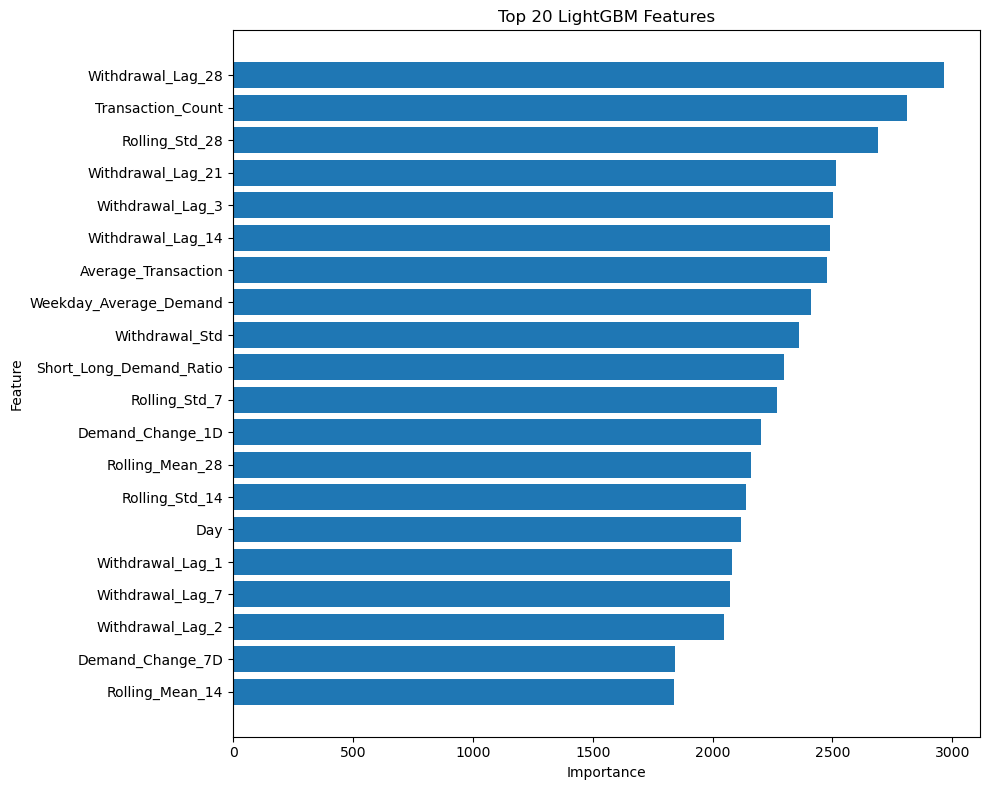

In [30]:
lgb_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": lightgbm_model.feature_importances_
})

lgb_importance = (
    lgb_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(lgb_importance.head(20))

plt.figure(figsize=(10, 8))
top_lgb = lgb_importance.head(20)
plt.barh(top_lgb["Feature"][::-1], top_lgb["Importance"][::-1])
plt.title("Top 20 LightGBM Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# XGBoost

In [31]:
xgboost_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=2000,
    learning_rate=0.02,
    max_depth=7,
    min_child_weight=5,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

xgboost_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [32]:
xgb_val_pred = xgboost_model.predict(X_val)
xgb_test_pred = xgboost_model.predict(X_test)

xgb_val_result = evaluate_model("XGBoost Validation", y_val, xgb_val_pred)
xgb_test_result = evaluate_model("XGBoost Test", y_test, xgb_test_pred)

XGBoost Validation
MAE      : 203,867.44
RMSE     : 293,262.76
MAPE     : 174.44%
R²       : 0.4470
XGBoost Test
MAE      : 180,276.30
RMSE     : 252,925.24
MAPE     : 123.29%
R²       : 0.5355


,Feature,Importance
0,Rolling_Mean_28,0.255013
1,EWMA_14,0.077009
2,DayOfWeek,0.070628
3,IsMonthStart,0.050036
4,Day,0.042432
5,Rolling_Mean_7,0.037398
6,Month,0.036286
7,EWMA_7,0.035529
8,WeekOfYear,0.024907
9,Transaction_Count,0.024663


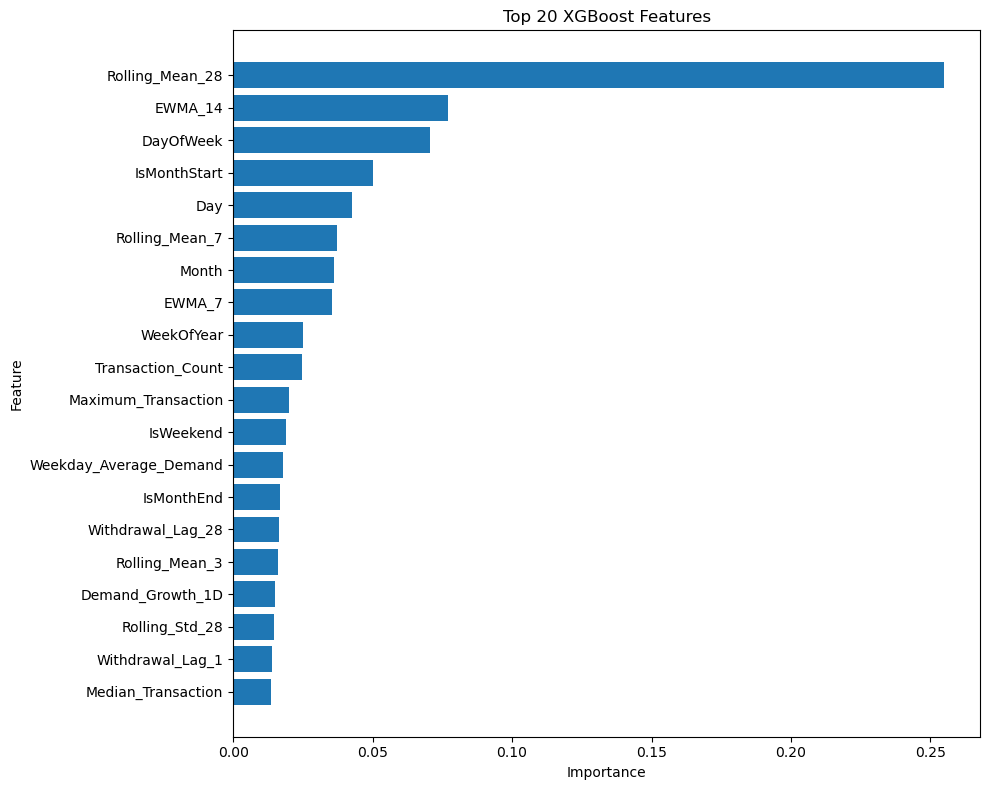

In [33]:
xgb_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": xgboost_model.feature_importances_
})

xgb_importance = (
    xgb_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(xgb_importance.head(20))

plt.figure(figsize=(10, 8))
top_xgb = xgb_importance.head(20)
plt.barh(top_xgb["Feature"][::-1], top_xgb["Importance"][::-1])
plt.title("Top 20 XGBoost Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# CatBoost

In [34]:
catboost_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=8,
    loss_function="RMSE",
    eval_metric="RMSE",
    l2_leaf_reg=5,
    random_seed=42,
    verbose=200,
    allow_writing_files=False
)

catboost_model.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    early_stopping_rounds=150,
    verbose=200
)

0:	learn: 361197.1344756	test: 390607.4184549	best: 390607.4184549 (0)	total: 64.2ms	remaining: 2m 8s
200:	learn: 216892.0692362	test: 292083.4099634	best: 292083.4099634 (200)	total: 3.48s	remaining: 31.2s
400:	learn: 196579.9550614	test: 291508.1378423	best: 291173.4868551 (373)	total: 6.97s	remaining: 27.8s
Stopped by overfitting detector  (150 iterations wait)

bestTest = 291173.4869
bestIteration = 373

Shrink model to first 374 iterations.


CatBoostRegressor(allow_writing_files=False, depth=8, eval_metric='RMSE', iterations=2000, l2_leaf_reg=5, learning_rate=0.03, loss_function='RMSE', random_seed=42, verbose=200)

In [35]:
cat_val_pred = catboost_model.predict(X_val)
cat_test_pred = catboost_model.predict(X_test)

cat_val_result = evaluate_model("CatBoost Validation", y_val, cat_val_pred)
cat_test_result = evaluate_model("CatBoost Test", y_test, cat_test_pred)

CatBoost Validation
MAE      : 206,320.62
RMSE     : 291,173.49
MAPE     : 197.01%
R²       : 0.4548
CatBoost Test
MAE      : 179,624.11
RMSE     : 249,861.14
MAPE     : 141.25%
R²       : 0.5466


,Feature,Importance
0,DayOfWeek,17.521521
1,Rolling_Mean_28,16.719617
2,Day,7.763885
3,Transaction_Count,6.132789
4,WeekOfYear,4.411625
5,IsWeekend,4.083566
6,Rolling_Mean_7,3.326451
7,EWMA_14,3.281515
8,Withdrawal_Lag_28,3.248418
9,Rolling_Mean_14,2.595835


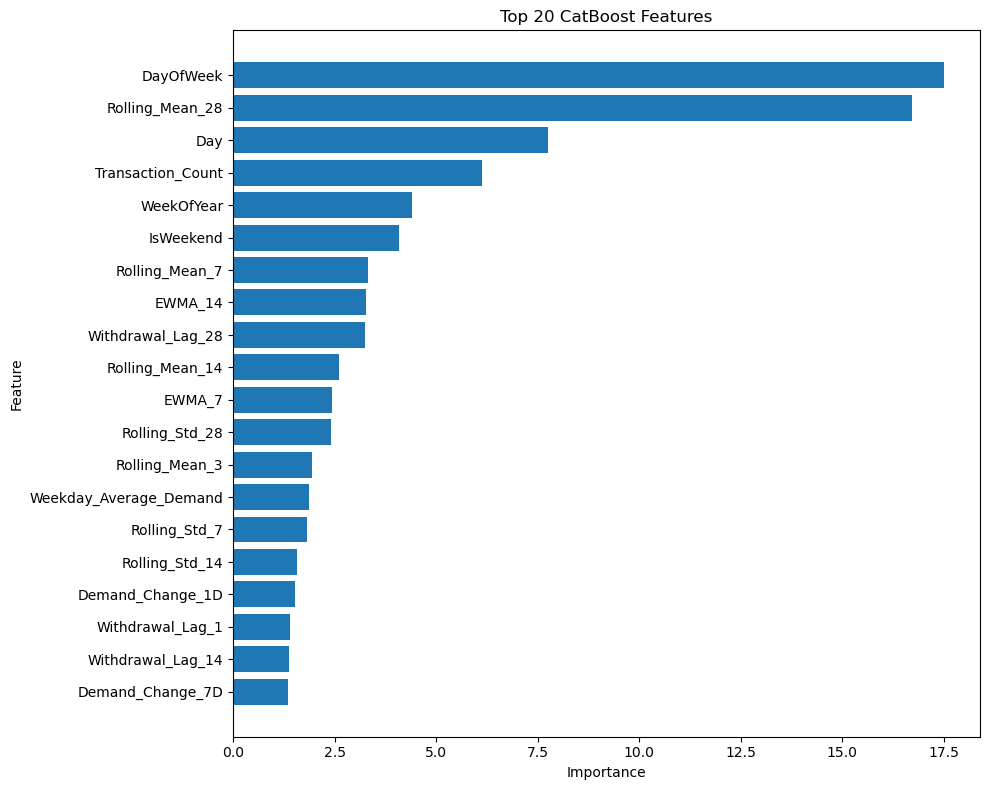

In [36]:
cat_importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": catboost_model.feature_importances_
})

cat_importance = (
    cat_importance
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

display(cat_importance.head(20))

plt.figure(figsize=(10, 8))
top_cat = cat_importance.head(20)
plt.barh(top_cat["Feature"][::-1], top_cat["Importance"][::-1])
plt.title("Top 20 CatBoost Features")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**MODEL COMPARISON**

In [38]:
validation_results = pd.DataFrame([lgb_val_result, xgb_val_result, cat_val_result])
test_results = pd.DataFrame([lgb_test_result, xgb_test_result, cat_test_result])

metric_cols = [
    "Model", "MAE", "RMSE", "MAPE (%)", "R2",
    "Precision", "Recall", "F1", "Accuracy (cls)", "High_Demand_Threshold",
]

print("VALIDATION RESULTS (sorted by RMSE)")
display(validation_results[metric_cols].sort_values("RMSE"))

print("\nTEST RESULTS (sorted by RMSE)")
display(test_results[metric_cols].sort_values("RMSE"))

print("\nTEST RESULTS (sorted by F1 — higher is better for high-demand detection)")
display(test_results[metric_cols].sort_values("F1", ascending=False))


VALIDATION RESULTS


,Model,MAE,RMSE,MAPE (%),R2
2,CatBoost Validation,206320.624976,291173.486855,197.010697,0.454823
1,XGBoost Validation,203867.443998,293262.764231,174.437691,0.446971
0,LightGBM Validation,206166.364028,298003.461179,180.616530,0.428947



TEST RESULTS


,Model,MAE,RMSE,MAPE (%),R2
0,LightGBM Test,177566.303489,249591.456096,118.390968,0.547624
2,CatBoost Test,179624.111597,249861.140948,141.254362,0.546645
1,XGBoost Test,180276.299002,252925.244431,123.292205,0.535458


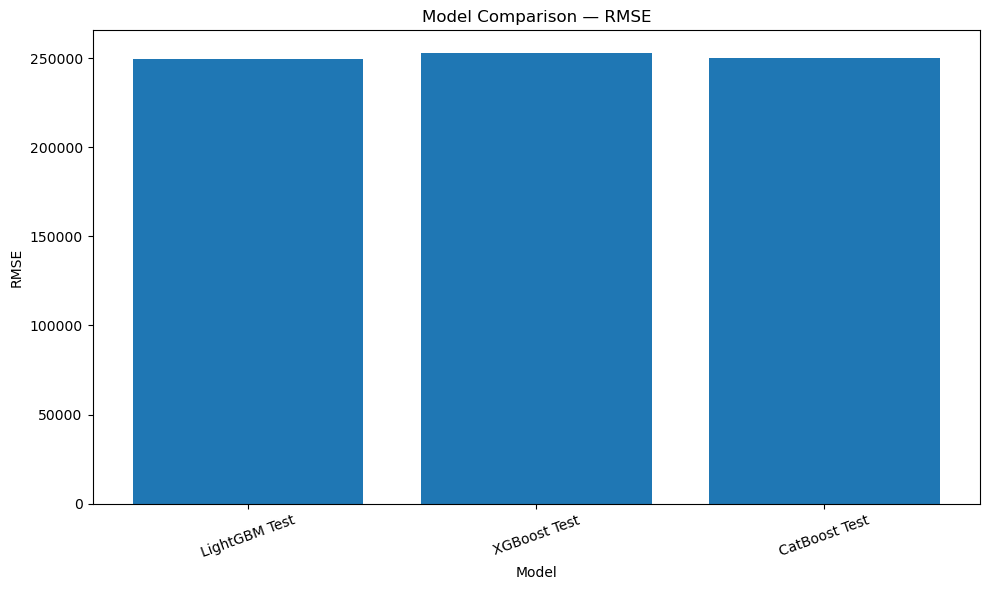

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(test_results["Model"], test_results["RMSE"])
ax.set_title("Model Comparison — RMSE")
ax.set_xlabel("Model")
ax.set_ylabel("RMSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

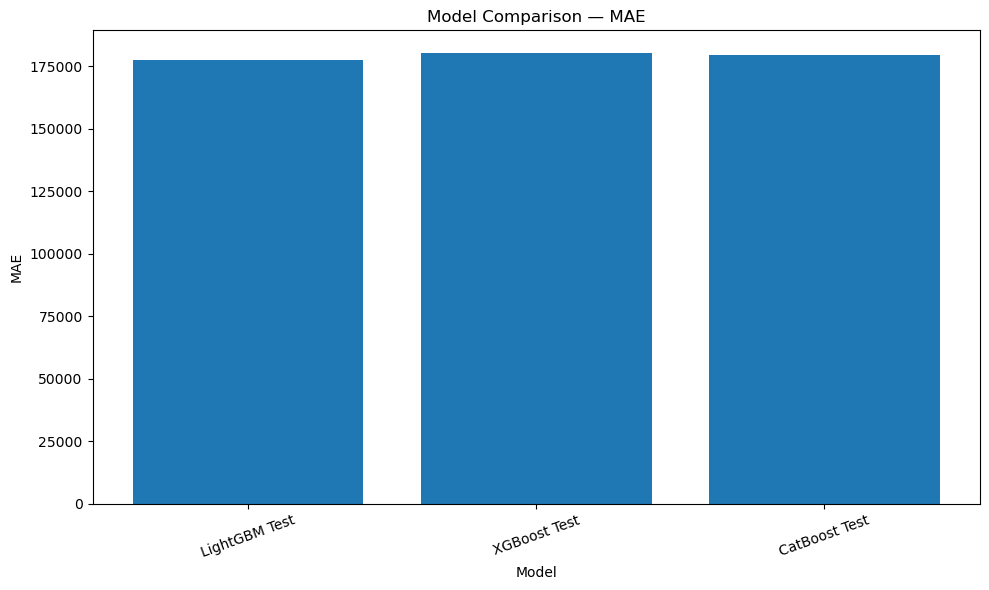

In [40]:
plt.figure(figsize=(10, 6))
plt.bar(test_results["Model"], test_results["MAE"])
plt.title("Model Comparison — MAE")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

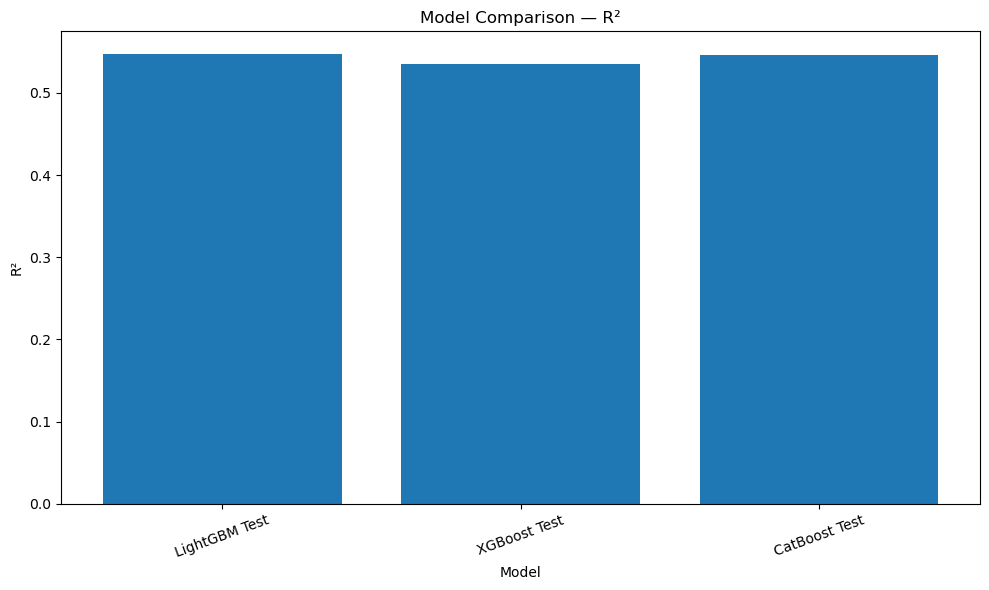

In [41]:
plt.figure(figsize=(10, 6))
plt.bar(test_results["Model"], test_results["R2"])
plt.title("Model Comparison — R²")
plt.xlabel("Model")
plt.ylabel("R²")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Operational classification metrics (Precision / Recall / F1)**

Because the target is continuous demand, Precision / Recall / F1 are computed by
labeling days as **high demand** when actual demand is at or above the 75th
percentile of the evaluation set. The same threshold is applied to predictions.

- **Precision** — of days predicted high-demand, how many truly were (fewer false refill trips)
- **Recall** — of true high-demand days, how many we caught (fewer stock-outs)
- **F1** — harmonic mean of Precision and Recall

For cash logistics, **recall** is often prioritized over precision.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for ax, metric, title in zip(
    axes,
    ["Precision", "Recall", "F1"],
    ["Precision (High Demand)", "Recall (High Demand)", "F1 (High Demand)"],
):
    ax.bar(test_results["Model"], test_results[metric], color=["#2563eb", "#dc2626", "#059669"])
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=15)
    for i, v in enumerate(test_results[metric]):
        ax.text(i, v + 0.02, f"{v:.3f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()


**Best Model**

In [42]:
test_results_sorted = (
    test_results
    .sort_values("RMSE")
    .reset_index(drop=True)
)

best_model_name = test_results_sorted.loc[0, "Model"]

print("BEST MODEL (lowest RMSE)")
print(best_model_name)

display(test_results_sorted.iloc[[0]][[
    "Model", "MAE", "RMSE", "MAPE (%)", "R2",
    "Precision", "Recall", "F1", "Accuracy (cls)", "High_Demand_Threshold",
]])

# Also show best by F1 (high-demand detection)
best_f1_row = test_results.sort_values("F1", ascending=False).iloc[0]
print("\nBEST MODEL BY F1 (high-demand detection)")
print(best_f1_row["Model"])
display(pd.DataFrame([best_f1_row])[[
    "Model", "MAE", "RMSE", "MAPE (%)", "R2",
    "Precision", "Recall", "F1", "Accuracy (cls)", "High_Demand_Threshold",
]])


BEST MODEL
LightGBM Test


,Model,MAE,RMSE,MAPE (%),R2
0,LightGBM Test,177566.303489,249591.456096,118.390968,0.547624


**Best Model Prediction**

In [43]:
if best_model_name == "LightGBM Test":
    best_predictions = lgb_test_pred
    best_model = lightgbm_model

elif best_model_name == "XGBoost Test":
    best_predictions = xgb_test_pred
    best_model = xgboost_model

elif best_model_name == "CatBoost Test":
    best_predictions = cat_test_pred
    best_model = catboost_model

else:
    raise ValueError(f"Unknown model: {best_model_name}")

comparison_df = test[["ATMID", "Date", "Target_Next_Day"]].copy()
comparison_df["Predicted_Next_Day"] = best_predictions

comparison_df["Absolute_Error"] = (
    comparison_df["Target_Next_Day"] - comparison_df["Predicted_Next_Day"]
).abs()

display(comparison_df.head(20))

,ATMID,Date,Target_Next_Day,Predicted_Next_Day,Absolute_Error
0,ABBAGR01,2024-03-17,1439000.0,903265.241432,535734.758568
1,ABBAGR02,2024-03-17,408000.0,421254.464440,13254.464440
2,ABBAND01,2024-03-17,510000.0,478565.823210,31434.176790
3,ABBASH01,2024-03-17,415500.0,292026.505542,123473.494458
4,ABBAST01,2024-03-17,589500.0,706489.290554,116989.290554
5,ABBATI01,2024-03-17,193500.0,157992.498853,35507.501147
6,ABBBAD01,2024-03-17,440000.0,713021.509899,273021.509899
7,ABBBAD02,2024-03-17,18500.0,65946.455602,47446.455602
8,ABBBAD03,2024-03-17,96500.0,65273.920238,31226.079762
9,ABBBAN01,2024-03-17,353500.0,753869.760178,400369.760178


**High-demand confusion matrix (best model, test set)**


In [ ]:
# Confusion matrix for the best model on the test set (high-demand classification)
best_row = test_results_sorted.iloc[0]
print("Best model for confusion matrix:", best_row["Model"] if "Model" in best_row else best_model_name)

# Rebuild high-demand labels using the same rule as evaluate_model
thr = np.percentile(y_test, 75)
y_true_cls = (np.asarray(y_test) >= thr).astype(int)
y_pred_cls = (np.asarray(best_predictions) >= thr).astype(int)

cm = confusion_matrix(y_true_cls, y_pred_cls)
print(f"High-demand threshold (P75 of test actual): {thr:,.0f}")
print("Confusion matrix [TN FP; FN TP]:")
print(cm)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pred Low", "Pred High"],
    yticklabels=["Actual Low", "Actual High"],
    ax=ax,
)
ax.set_title(f"High-Demand Confusion Matrix — {best_model_name}")
plt.tight_layout()
plt.show()

print(f"Precision : {precision_score(y_true_cls, y_pred_cls, zero_division=0):.4f}")
print(f"Recall    : {recall_score(y_true_cls, y_pred_cls, zero_division=0):.4f}")
print(f"F1        : {f1_score(y_true_cls, y_pred_cls, zero_division=0):.4f}")


In [ ]:
# Full-period predictions (entire combined Jan–Dec 2024 range), across train, validation, and test
X_full = model_df[feature_cols].copy()

full_predictions = best_model.predict(X_full)

full_comparison_df = model_df[["ATMID", "Date", "Target_Next_Day"]].copy()
full_comparison_df["Predicted_Next_Day"] = full_predictions

full_comparison_df["Absolute_Error"] = (
    full_comparison_df["Target_Next_Day"] - full_comparison_df["Predicted_Next_Day"]
).abs()

full_comparison_df["Split"] = np.select(
    [full_comparison_df["Date"].isin(train_dates),
     full_comparison_df["Date"].isin(validation_dates),
     full_comparison_df["Date"].isin(test_dates)],
    ["Train", "Validation", "Test"],
    default="Unknown"
)

full_comparison_df = (
    full_comparison_df.sort_values(["ATMID", "Date"]).reset_index(drop=True)
)

print("Full comparison date range:", full_comparison_df["Date"].min(), "→", full_comparison_df["Date"].max())
print(full_comparison_df["Split"].value_counts())
display(full_comparison_df.head(20))

**CONSERVATIVE ATM CASH LOADING POLICY**

In [45]:
full_comparison_df["Predicted_Demand"] = (
    full_comparison_df["Predicted_Next_Day"].clip(lower=0)
)

# Conservative safety factor
SAFETY_FACTOR = 1.05

full_comparison_df["Recommended_Loading"] = (
    full_comparison_df["Predicted_Demand"] * SAFETY_FACTOR
)

print("Safety factor:", SAFETY_FACTOR)
display(full_comparison_df.head(20))

Safety factor: 1.05


,ATMID,Date,Target_Next_Day,Predicted_Next_Day,Absolute_Error,Split,Predicted_Demand,Recommended_Loading
0,ABBAGR01,2024-01-29,722500.0,7.237229e+05,1222.850933,Train,7.237229e+05,7.599090e+05
1,ABBAGR01,2024-01-30,1122500.0,1.101596e+06,20903.680165,Train,1.101596e+06,1.156676e+06
2,ABBAGR01,2024-01-31,851000.0,9.259408e+05,74940.787027,Train,9.259408e+05,9.722378e+05
3,ABBAGR01,2024-02-01,421500.0,4.374494e+05,15949.355181,Train,4.374494e+05,4.593218e+05
4,ABBAGR01,2024-02-02,505500.0,6.014673e+05,95967.269523,Train,6.014673e+05,6.315406e+05
5,ABBAGR01,2024-02-03,1197000.0,1.071310e+06,125689.539366,Train,1.071310e+06,1.124876e+06
6,ABBAGR01,2024-02-04,988500.0,9.436261e+05,44873.935596,Train,9.436261e+05,9.908074e+05
7,ABBAGR01,2024-02-05,1126000.0,1.064937e+06,61062.641100,Train,1.064937e+06,1.118184e+06
8,ABBAGR01,2024-02-06,1195000.0,1.090256e+06,104744.236837,Train,1.090256e+06,1.144769e+06
9,ABBAGR01,2024-02-07,1247000.0,1.114842e+06,132157.900286,Train,1.114842e+06,1.170584e+06


In [46]:
# Save final feature-engineered dataset
output_file = os.path.join(OUTPUT_DIR, "ATM_Cash_Forecasting_Feature_Engineered.csv")
df.to_csv(output_file, index=False)

# Verify
print(f"File saved: {output_file}")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print("Columns:", list(df.columns))


File saved: ./ATM_Cash_Forecasting_Feature_Engineered.csv
Rows: 21,675
Columns: 43
Columns: ['ATMID', 'Date', 'Daily_Withdrawal', 'Transaction_Count', 'Average_Transaction', 'Median_Transaction', 'Maximum_Transaction', 'Minimum_Transaction', 'Withdrawal_Std', 'Day', 'Month', 'Year', 'DayOfWeek', 'WeekOfYear', 'Quarter', 'IsWeekend', 'IsMonthStart', 'IsMonthEnd', 'Withdrawal_Lag_1', 'Withdrawal_Lag_2', 'Withdrawal_Lag_3', 'Withdrawal_Lag_7', 'Withdrawal_Lag_14', 'Withdrawal_Lag_21', 'Withdrawal_Lag_28', 'Rolling_Mean_3', 'Rolling_Mean_7', 'Rolling_Mean_14', 'Rolling_Mean_28', 'Rolling_Std_7', 'Rolling_Std_14', 'Rolling_Std_28', 'EWMA_7', 'EWMA_14', 'Demand_Change_1D', 'Demand_Change_7D', 'Demand_Growth_1D', 'Demand_Growth_7D', 'Short_Long_Demand_Ratio', 'Transaction_Intensity', 'Average_Transaction_Change', 'Weekday_Average_Demand', 'Target_Next_Day']


**ATM CASH CAPACITY CONSTRAINT**

In [47]:
ATM_MAX_CAPACITY = 1500000

full_comparison_df["Recommended_Loading"] = (
    full_comparison_df["Recommended_Loading"].clip(lower=0, upper=ATM_MAX_CAPACITY)
)

print("Maximum allowed loading:", ATM_MAX_CAPACITY)

Maximum allowed loading: 1500000


**CASH LOADING ROUNDING**

In [48]:
CASH_UNIT = 500

full_comparison_df["Recommended_Loading"] = (
    np.ceil(full_comparison_df["Recommended_Loading"] / CASH_UNIT) * CASH_UNIT
)

display(
    full_comparison_df[["ATMID", "Date", "Predicted_Demand", "Recommended_Loading"]].head(20)
)

,ATMID,Date,Predicted_Demand,Recommended_Loading
0,ABBAGR01,2024-01-29,7.237229e+05,760000.0
1,ABBAGR01,2024-01-30,1.101596e+06,1157000.0
2,ABBAGR01,2024-01-31,9.259408e+05,972500.0
3,ABBAGR01,2024-02-01,4.374494e+05,459500.0
4,ABBAGR01,2024-02-02,6.014673e+05,632000.0
5,ABBAGR01,2024-02-03,1.071310e+06,1125000.0
6,ABBAGR01,2024-02-04,9.436261e+05,991000.0
7,ABBAGR01,2024-02-05,1.064937e+06,1118500.0
8,ABBAGR01,2024-02-06,1.090256e+06,1145000.0
9,ABBAGR01,2024-02-07,1.114842e+06,1171000.0


**IDLE CASH CONTROL**

In [49]:
full_comparison_df["Expected_Excess_Cash"] = (
   full_comparison_df["Recommended_Loading"] - full_comparison_df["Predicted_Demand"]
)

full_comparison_df["Excess_Cash_Percentage"] = np.where(
    full_comparison_df["Predicted_Demand"] > 0,
    (full_comparison_df["Expected_Excess_Cash"] / full_comparison_df["Predicted_Demand"]) * 100,
    0
)

display(
   full_comparison_df[[
        "ATMID", "Date", "Predicted_Demand",
        "Recommended_Loading", "Expected_Excess_Cash", "Excess_Cash_Percentage"
    ]].head(20)
)

,ATMID,Date,Predicted_Demand,Recommended_Loading,Expected_Excess_Cash,Excess_Cash_Percentage
0,ABBAGR01,2024-01-29,7.237229e+05,760000.0,36277.149067,5.012575
1,ABBAGR01,2024-01-30,1.101596e+06,1157000.0,55403.680165,5.029400
2,ABBAGR01,2024-01-31,9.259408e+05,972500.0,46559.212973,5.028314
3,ABBAGR01,2024-02-01,4.374494e+05,459500.0,22050.644819,5.040731
4,ABBAGR01,2024-02-02,6.014673e+05,632000.0,30532.730477,5.076374
5,ABBAGR01,2024-02-03,1.071310e+06,1125000.0,53689.539366,5.011576
6,ABBAGR01,2024-02-04,9.436261e+05,991000.0,47373.935596,5.020414
7,ABBAGR01,2024-02-05,1.064937e+06,1118500.0,53562.641100,5.029652
8,ABBAGR01,2024-02-06,1.090256e+06,1145000.0,54744.236837,5.021229
9,ABBAGR01,2024-02-07,1.114842e+06,1171000.0,56157.900286,5.037296


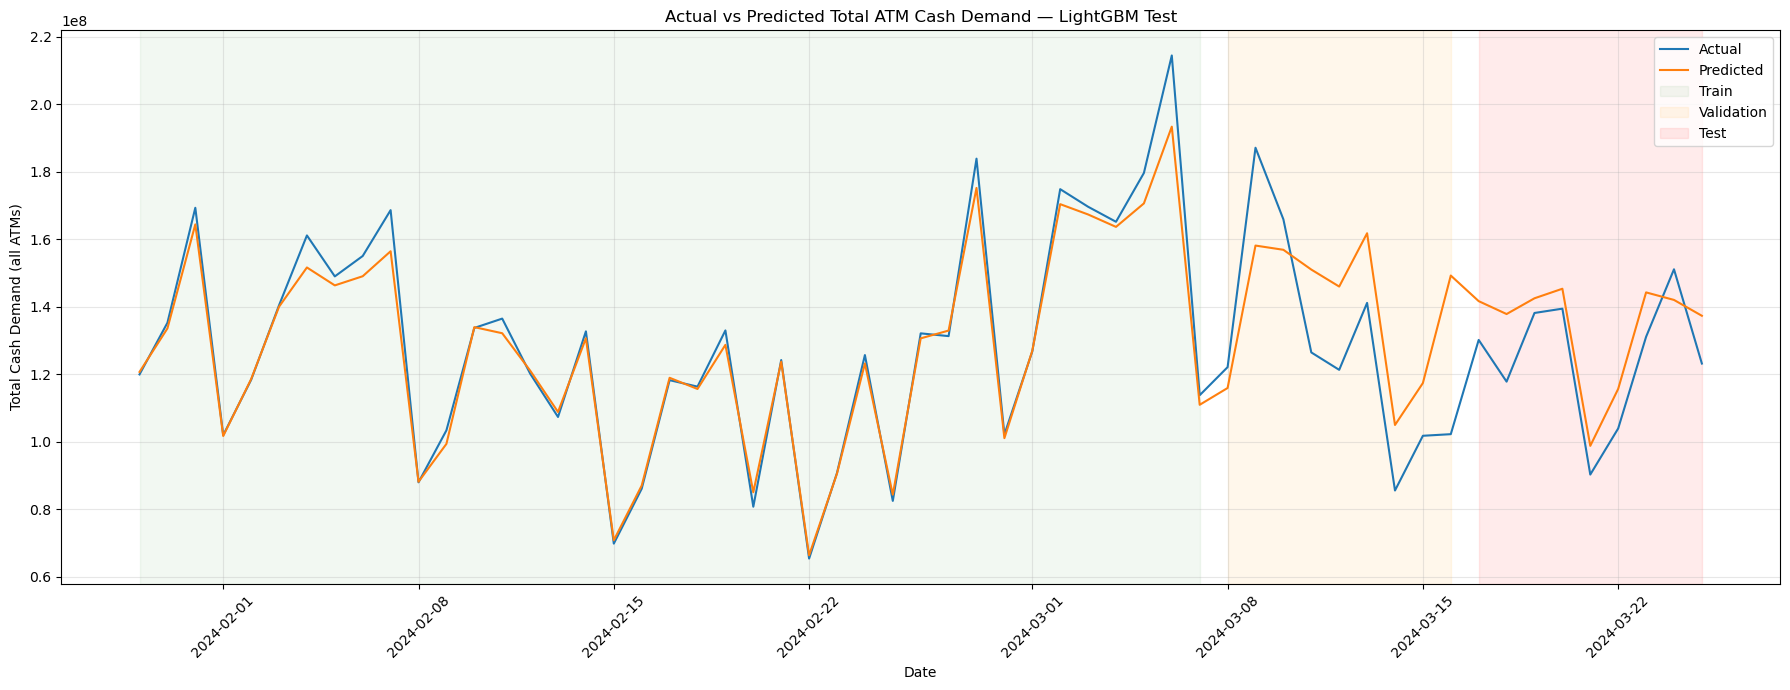

In [50]:
daily_actual_vs_pred = (
    full_comparison_df
    .groupby("Date")[["Target_Next_Day", "Predicted_Next_Day"]]
    .sum()
    .reset_index()
)

plt.figure(figsize=(18, 7))
plt.plot(daily_actual_vs_pred["Date"], daily_actual_vs_pred["Target_Next_Day"], label="Actual")
plt.plot(daily_actual_vs_pred["Date"], daily_actual_vs_pred["Predicted_Next_Day"], label="Predicted")

plt.axvspan(train_dates.min(), train_dates.max(), color="green", alpha=0.05, label="Train")
plt.axvspan(validation_dates.min(), validation_dates.max(), color="orange", alpha=0.08, label="Validation")
plt.axvspan(test_dates.min(), test_dates.max(), color="red", alpha=0.08, label="Test")

plt.title(f"Actual vs Predicted Total ATM Cash Demand — {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Total Cash Demand (all ATMs)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# The predicted cash

In [ ]:
full_comparison_df.to_csv(
    os.path.join(OUTPUT_DIR, "ATM_Cash_Forecasting_Full_Year_Predictions.csv"),
    index=False
)
print("Saved: ATM_Cash_Forecasting_Full_Year_Predictions.csv")

**ACTUAL VS PREDICTED**

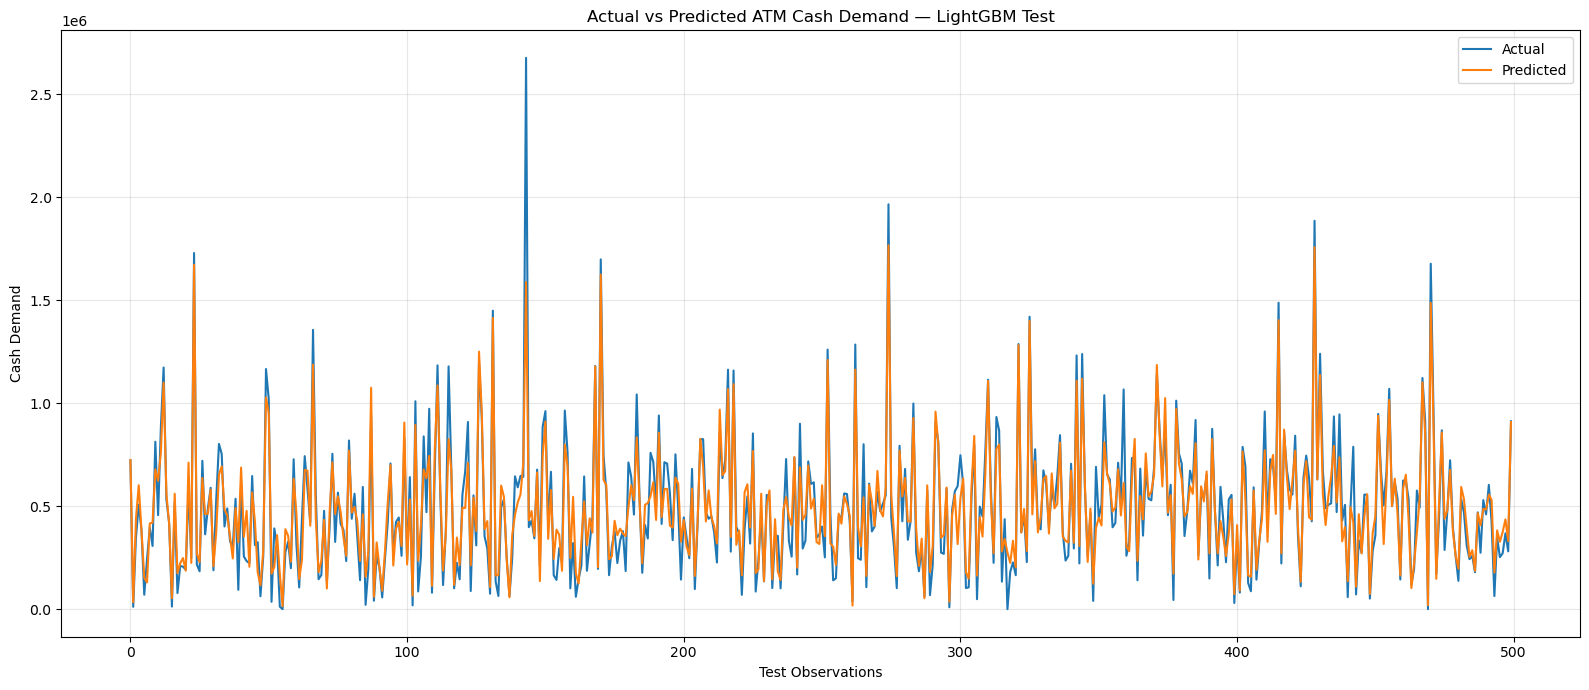

In [52]:
plot_df = full_comparison_df.sort_values("Date").reset_index(drop=True)

plt.figure(figsize=(16, 7))
plt.plot(plot_df["Target_Next_Day"].values[:500], label="Actual")
plt.plot(plot_df["Predicted_Next_Day"].values[:500], label="Predicted")

plt.title(f"Actual vs Predicted ATM Cash Demand — {best_model_name}")
plt.xlabel("Test Observations")
plt.ylabel("Cash Demand")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**ATM-LEVEL MODEL PERFORMANCE**

In [53]:
atm_results = []

for atm_id, group in full_comparison_df.groupby("ATMID"):
    actual = group["Target_Next_Day"].values
    predicted = group["Predicted_Next_Day"].values

    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))

    atm_results.append({
        "ATMID": atm_id,
        "MAE": mae,
        "RMSE": rmse,
        "Average_Actual_Demand": actual.mean(),
        "Average_Predicted_Demand": predicted.mean()
    })

atm_performance = pd.DataFrame(atm_results)
atm_performance = atm_performance.sort_values("RMSE").reset_index(drop=True)

display(atm_performance.head(20))

,ATMID,MAE,RMSE,Average_Actual_Demand,Average_Predicted_Demand
0,ABBGUL10,38356.577806,48595.396432,53219.298246,66065.790527
1,ABBTON02,37712.871450,51069.660448,38754.385965,59006.155676
2,ABBBOG06,42375.957277,53835.049092,65885.964912,86864.815165
3,ABBBOK01,52326.179865,66553.687923,131631.578947,140376.056924
4,ABBCDA03,49188.229467,70361.865008,132578.947368,139398.847020
5,ABBBAR06,51733.579798,72857.737005,116070.175439,130620.616471
6,ABBATI01,58705.759616,73030.963986,144307.017544,156272.401228
7,ABBKAR02,54021.335457,73184.191976,127578.947368,130742.942749
8,ABBELP03,60973.342670,74979.890498,175824.561404,202478.219625
9,ABBBIJ01,57314.064426,77079.345657,164333.333333,169521.027293


In [54]:
# Check the dataset
print("Rows:", len(atm_performance))
print("Columns:", list(atm_performance.columns))

display(atm_performance.head())

# Save locally
file_name_out = os.path.join(OUTPUT_DIR, "ATM_Level_Model_Performance.csv")
atm_performance.to_csv(file_name_out, index=False)
print("Saved:", file_name_out)


Rows: 255
Columns: ['ATMID', 'MAE', 'RMSE', 'Average_Actual_Demand', 'Average_Predicted_Demand']


,ATMID,MAE,RMSE,Average_Actual_Demand,Average_Predicted_Demand
0,ABBGUL10,38356.577806,48595.396432,53219.298246,66065.790527
1,ABBTON02,37712.871450,51069.660448,38754.385965,59006.155676
2,ABBBOG06,42375.957277,53835.049092,65885.964912,86864.815165
3,ABBBOK01,52326.179865,66553.687923,131631.578947,140376.056924
4,ABBCDA03,49188.229467,70361.865008,132578.947368,139398.847020


Saved: ./ATM_Level_Model_Performance.csv


**Worst Performing ATMs**

In [55]:
display(
    atm_performance.sort_values("RMSE", ascending=False).head(20)
)

,ATMID,MAE,RMSE,Average_Actual_Demand,Average_Predicted_Demand
254,ABBCHT02,394905.377051,786546.335999,8.922719e+05,7.959574e+05
253,ABBJIN01,364223.878308,634772.582371,1.630789e+06,1.392040e+06
252,ABBCHT01,314410.340823,603363.349183,1.001132e+06,9.074213e+05
251,ABBPRI01,300870.800882,534591.567828,1.025333e+06,1.082445e+06
250,ABBCEP01,223396.465549,529753.860224,7.069474e+05,5.855193e+05
249,ABBGAZ03,198353.684987,452209.198710,4.575439e+05,3.746662e+05
248,ABBIMM01,244979.728632,445542.444616,1.172404e+06,1.202341e+06
247,ABBSAI02,201117.671711,429591.342481,3.956754e+05,3.441807e+05
246,ABBSED01,221190.439316,415249.344626,5.705263e+05,5.090081e+05
245,ABBBRD07,240985.053043,405276.049642,7.598684e+05,7.150242e+05


In [56]:
test_results_sorted.to_csv(os.path.join(OUTPUT_DIR, "ATM_Model_Comparison.csv"), index=False)
comparison_df.to_csv(os.path.join(OUTPUT_DIR, "ATM_Test_Predictions.csv"), index=False)
atm_performance.to_csv(os.path.join(OUTPUT_DIR, "ATM_Level_Performance.csv"), index=False)


In [57]:
joblib.dump(best_model, os.path.join(OUTPUT_DIR, "Best_ATM_Cash_Forecasting_Model.pkl"))
print("Best model saved successfully:")
print("Best_ATM_Cash_Forecasting_Model.pkl")


Best model saved successfully:
Best_ATM_Cash_Forecasting_Model.pkl


In [58]:
joblib.dump(feature_cols, os.path.join(OUTPUT_DIR, "ATM_Forecasting_Feature_List.pkl"))
print("Feature list saved successfully.")
print("Number of features:", len(feature_cols))


Feature list saved successfully.
Number of features: 36


In [59]:
forecasting_package = {
    "model": best_model,
    "feature_columns": feature_cols,
    "model_name": best_model_name,
    "training_date_start": train["Date"].min(),
    "training_date_end": train["Date"].max(),
    "validation_date_start": validation["Date"].min(),
    "validation_date_end": validation["Date"].max(),
    "test_date_start": test["Date"].min(),
    "test_date_end": test["Date"].max()
}

joblib.dump(forecasting_package, os.path.join(OUTPUT_DIR, "ATM_Cash_Forecasting_Package.pkl"))
print("Complete forecasting package saved.")


Complete forecasting package saved.


In [60]:
output_files = [
    "Best_ATM_Cash_Forecasting_Model.pkl",
    "ATM_Forecasting_Feature_List.pkl",
    "ATM_Cash_Forecasting_Package.pkl",
    "ATM_Model_Comparison.csv",
    "ATM_Test_Predictions.csv",
    "ATM_Level_Performance.csv"
]

print("Saved files:")
for file_name_check in output_files:
    full_path = os.path.join(OUTPUT_DIR, file_name_check)
    status = "OK" if os.path.exists(full_path) else "MISSING"
    print(f"  [{status}] {full_path}")


Saved files:
  [OK] ./Best_ATM_Cash_Forecasting_Model.pkl
  [OK] ./ATM_Forecasting_Feature_List.pkl
  [OK] ./ATM_Cash_Forecasting_Package.pkl
  [OK] ./ATM_Model_Comparison.csv
  [OK] ./ATM_Test_Predictions.csv
  [OK] ./ATM_Level_Performance.csv


In [ ]:
output_file = os.path.join(OUTPUT_DIR, "ATM_Cash_Forecasting_Feature_Engineered_Full_Year.csv")
df.to_csv(output_file, index=False)

print(f"File saved: {output_file}")
print(f"Rows: {len(df):,}")
print(f"Columns: {len(df.columns)}")
print("Columns:", list(df.columns))

# ATM Cash Management Dashboard — Full Year 2024

Interactive **enhanced** dashboard built on the combined Jan–Dec 2024 data.  
Includes Days of Cash, multi-filters, sortable table, progress bar, and responsive layout.


No extra installs needed for this part — the dashboard is now a self-contained HTML page (Plotly loads from its CDN inside that page), opened with Python's built-in `webbrowser` module.

**Build a realistic cash-balance simulation per ATM**


In [63]:
REORDER_THRESHOLD_PCT = 20     # <= this % of capacity -> "Refill Now"
MEDIUM_CASH_THRESHOLD_PCT = 40  # <= this % of capacity -> "Refill Soon"
CAPACITY_BUFFER = 1.5           # each ATM's vault sized at 1.5x its own historical peak loading

latest_date = full_comparison_df["Date"].max()

# Size each ATM's vault to its own demand pattern, not one fixed number for all ATMs
atm_capacity = (
    full_comparison_df.groupby("ATMID")["Recommended_Loading"]
    .max()
    .mul(CAPACITY_BUFFER)
    .rename("ATM_Capacity")
)

# Simulate a running cash balance per ATM: start full, draw down by predicted
# demand each day, and refill back to full whenever the balance hits the
# reorder threshold.
sim_records = []
for atm_id, group in full_comparison_df.sort_values(["ATMID", "Date"]).groupby("ATMID"):
    capacity = atm_capacity.loc[atm_id]
    reorder_point = capacity * REORDER_THRESHOLD_PCT / 100
    balance = capacity
    for row in group.itertuples():
        demand = max(row.Predicted_Next_Day, 0)
        balance = max(balance - demand, 0)
        if balance <= reorder_point:
            balance = capacity  # refill event
        sim_records.append({"ATMID": atm_id, "Date": row.Date, "Cash_Balance": balance})

cash_sim_df = pd.DataFrame(sim_records)

# ---------- Build today's status table from the simulated balance ----------
today_df = full_comparison_df[full_comparison_df["Date"] == latest_date].copy()
today_df = today_df.merge(
    cash_sim_df[cash_sim_df["Date"] == latest_date][["ATMID", "Cash_Balance"]],
    on="ATMID", how="left"
)
today_df = today_df.merge(atm_capacity, on="ATMID", how="left")

today_df["Estimated_Cash_Remaining"] = today_df["Cash_Balance"]
today_df["Cash_Remaining_Pct"] = (
    today_df["Estimated_Cash_Remaining"] / today_df["ATM_Capacity"] * 100
).round(1)

def refill_flag(pct):
    if pct <= REORDER_THRESHOLD_PCT:
        return "Refill Now"
    elif pct <= MEDIUM_CASH_THRESHOLD_PCT:
        return "Refill Soon"
    else:
        return "OK"

today_df["Status"] = today_df["Cash_Remaining_Pct"].apply(refill_flag)

today_df["Refill_Suggestion_Amount"] = (
    (today_df["ATM_Capacity"] - today_df["Estimated_Cash_Remaining"]).clip(lower=0)
)
today_df["Refill_Suggestion_Amount"] = (
    np.ceil(today_df["Refill_Suggestion_Amount"] / CASH_UNIT) * CASH_UNIT
)

# Location: use it if the feature dataset has it, otherwise fall back to a readable label
loc_col = next((c for c in df.columns if "location" in c.lower()), None)
if loc_col:
    loc_map = df.drop_duplicates("ATMID").set_index("ATMID")[loc_col]
    today_df["Location"] = today_df["ATMID"].map(loc_map)
else:
    today_df["Location"] = "ATM " + today_df["ATMID"].astype(str) + " (location not in dataset)"

today_df = today_df.sort_values("Cash_Remaining_Pct").reset_index(drop=True)

print("Status as of:", latest_date.date())
print("Status counts:")
print(today_df["Status"].value_counts())
display(today_df[["ATMID", "Location", "ATM_Capacity", "Estimated_Cash_Remaining",
                   "Cash_Remaining_Pct", "Refill_Suggestion_Amount", "Status"]].head(10))


Status as of: 2024-03-25
Status counts:
Status
OK             217
Refill Soon     38
Name: count, dtype: int64


,ATMID,Location,ATM_Capacity,Estimated_Cash_Remaining,Cash_Remaining_Pct,Refill_Suggestion_Amount,Status
0,ABBDIN01,ATM ABBDIN01 (location not in dataset),1210500.0,246504.388733,20.4,964000.0,Refill Soon
1,ABBKHU04,ATM ABBKHU04 (location not in dataset),626250.0,128391.719820,20.5,498000.0,Refill Soon
2,ABBGAR01,ATM ABBGAR01 (location not in dataset),1161750.0,244440.895838,21.0,917500.0,Refill Soon
3,ABBBEN02,ATM ABBBEN02 (location not in dataset),1690500.0,362972.445244,21.5,1328000.0,Refill Soon
4,ABBBHA01,ATM ABBBHA01 (location not in dataset),2250000.0,500891.583212,22.3,1749500.0,Refill Soon
5,ABBLOH02,ATM ABBLOH02 (location not in dataset),1782000.0,398909.488160,22.4,1383500.0,Refill Soon
6,ABBCEP02,ATM ABBCEP02 (location not in dataset),2014500.0,465805.770169,23.1,1549000.0,Refill Soon
7,ABBBOG02,ATM ABBBOG02 (location not in dataset),2064000.0,482915.939142,23.4,1581500.0,Refill Soon
8,ABBFRD01,ATM ABBFRD01 (location not in dataset),1349250.0,325862.595306,24.2,1023500.0,Refill Soon
9,ABBNSR03,ATM ABBNSR03 (location not in dataset),859500.0,209829.974295,24.4,650000.0,Refill Soon


**Build the dashboard as a standalone page and open it in a new tab**

Same two controls as before — a **search box** and the **ATM dropdown** it filters — but instead of rendering inline under this cell, the dashboard is written out as a self-contained `.html` file and opened in a new browser tab, so it has its own window separate from the notebook.

In [ ]:
import json
import webbrowser
import numpy as np

status_colors = {"Refill Now": "#dc2626", "Refill Soon": "#d97706", "OK": "#059669"}
status_tints = {"Refill Now": "#fef2f2", "Refill Soon": "#fffbeb", "OK": "#ecfdf5"}

# ---------- Prepare ATM records with Days of Cash ----------
atm_records = today_df[[
    "ATMID", "Location", "ATM_Capacity", "Estimated_Cash_Remaining",
    "Cash_Remaining_Pct", "Predicted_Demand", "Refill_Suggestion_Amount", "Status"
]].copy()

atm_records["ATMID"] = atm_records["ATMID"].astype(str).str.strip()
atm_records["Location"] = atm_records["Location"].astype(str).str.strip()

# Days of Cash = remaining cash / predicted next-day demand
atm_records["Days_of_Cash"] = (
    atm_records["Estimated_Cash_Remaining"] /
    atm_records["Predicted_Demand"].clip(lower=1e-6)
).round(1)

atm_records = atm_records.round({
    "ATM_Capacity": 0,
    "Estimated_Cash_Remaining": 0,
    "Cash_Remaining_Pct": 1,
    "Predicted_Demand": 0,
    "Refill_Suggestion_Amount": 0,
})

# Sort most urgent first
atm_records = atm_records.sort_values(
    ["Status", "Days_of_Cash", "Cash_Remaining_Pct"],
    key=lambda col: col.map({"Refill Now": 0, "Refill Soon": 1, "OK": 2}) if col.name == "Status" else col
).reset_index(drop=True)

atm_data_json = atm_records.to_dict(orient="records")

# ---------- KPI totals ----------
total_atms = int(atm_records["ATMID"].nunique())
refill_now_count = int((atm_records["Status"] == "Refill Now").sum())
refill_soon_count = int((atm_records["Status"] == "Refill Soon").sum())
total_refill_amount = float(atm_records["Refill_Suggestion_Amount"].sum())
critical_days = int((atm_records["Days_of_Cash"] < 1.0).sum())
avg_days = float(atm_records["Days_of_Cash"].mean())
total_capacity = float(atm_records["ATM_Capacity"].sum())
total_remaining = float(atm_records["Estimated_Cash_Remaining"].sum())
util_pct = round(total_remaining / total_capacity * 100, 1) if total_capacity else 0

# ---------- Full actual-vs-predicted history per ATM ----------
history = {}
for atm_id, group in full_comparison_df.sort_values(["ATMID", "Date"]).groupby("ATMID"):
    history[str(atm_id).strip()] = {
        "dates": group["Date"].dt.strftime("%Y-%m-%d").tolist(),
        "actual": group["Target_Next_Day"].round(0).tolist(),
        "predicted": group["Predicted_Next_Day"].round(0).tolist(),
    }

HTML_TEMPLATE = r"""<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>ATM Cash Management Dashboard</title>
<script src="https://cdn.plot.ly/plotly-2.35.2.min.js"></script>
<style>
  :root {
    --navy: #1e3a5f; --navy-light: #2c4a6e; --grey: #6b7280;
    --red: #dc2626; --orange: #d97706; --green: #059669;
    --card-shadow: 0 1px 3px rgba(0,0,0,0.08), 0 1px 2px rgba(0,0,0,0.06);
    --radius: 12px;
  }
  * { box-sizing: border-box; margin: 0; padding: 0; }
  body {
    font-family: 'Segoe UI', system-ui, -apple-system, sans-serif;
    background: #f0f2f5; color: #1f2937; line-height: 1.5;
    padding: 16px; min-height: 100vh;
  }
  .container { max-width: 1400px; margin: 0 auto; }
  header {
    display: flex; flex-wrap: wrap; justify-content: space-between;
    align-items: center; margin-bottom: 20px; gap: 12px;
  }
  h1 { font-size: 1.6rem; color: var(--navy); font-weight: 700; }
  .last-updated {
    font-size: 0.85rem; color: var(--grey); background: white;
    padding: 6px 12px; border-radius: 20px; box-shadow: var(--card-shadow);
  }
  .kpi-row {
    display: grid; grid-template-columns: repeat(auto-fit, minmax(140px, 1fr));
    gap: 12px; margin-bottom: 24px;
  }
  .kpi-card {
    background: white; border-radius: var(--radius); padding: 16px;
    box-shadow: var(--card-shadow); text-align: center; transition: transform 0.15s;
  }
  .kpi-card:hover { transform: translateY(-2px); }
  .kpi-title { color: var(--grey); font-size: 0.72rem; text-transform: uppercase; letter-spacing: 0.5px; font-weight: 600; }
  .kpi-value { font-size: 1.7rem; font-weight: 700; margin-top: 4px; line-height: 1.2; }
  .kpi-sub { font-size: 0.75rem; color: var(--grey); margin-top: 2px; }
  .filters-bar {
    background: white; border-radius: var(--radius); padding: 16px;
    box-shadow: var(--card-shadow); margin-bottom: 20px;
    display: flex; flex-wrap: wrap; gap: 12px; align-items: flex-end;
  }
  .filter-group { display: flex; flex-direction: column; gap: 4px; }
  .filter-group label { font-size: 0.75rem; font-weight: 600; color: var(--grey); text-transform: uppercase; }
  .filters-bar input, .filters-bar select {
    font-size: 0.9rem; padding: 8px 12px; border: 1px solid #d1d5db;
    border-radius: 8px; background: #fff; min-width: 140px;
  }
  .filters-bar input:focus, .filters-bar select:focus {
    outline: none; border-color: var(--navy); box-shadow: 0 0 0 3px rgba(30,58,95,0.15);
  }
  .filters-bar input { min-width: 200px; }
  .match-count { font-size: 0.8rem; color: var(--grey); align-self: center; margin-left: auto; }
  .btn {
    padding: 8px 16px; border: none; border-radius: 8px; font-size: 0.85rem;
    font-weight: 600; cursor: pointer; transition: background 0.15s;
  }
  .btn-secondary { background: #e5e7eb; color: #374151; }
  .btn-secondary:hover { background: #d1d5db; }
  .detail-chart-row {
    display: grid; grid-template-columns: 320px 1fr; gap: 16px; margin-bottom: 24px;
  }
  @media (max-width: 900px) { .detail-chart-row { grid-template-columns: 1fr; } }
  .detail-card {
    background: white; border-radius: var(--radius); padding: 20px;
    box-shadow: var(--card-shadow);
  }
  .detail-card .atm-id { font-size: 1.25rem; font-weight: 700; color: var(--navy); }
  .detail-card .atm-loc { color: var(--grey); font-size: 0.9rem; margin-bottom: 10px; }
  .status-badge {
    display: inline-block; color: white; padding: 4px 14px;
    border-radius: 20px; font-weight: 600; font-size: 0.8rem; margin-bottom: 14px;
  }
  .detail-card hr { border: none; border-top: 1px solid #e5e7eb; margin: 12px 0; }
  .detail-metric {
    display: flex; justify-content: space-between; padding: 6px 0;
    font-size: 0.9rem; border-bottom: 1px solid #f3f4f6;
  }
  .detail-metric:last-child { border-bottom: none; }
  .detail-metric .label { color: var(--grey); }
  .detail-metric .value { font-weight: 600; }
  .progress-bar-wrap {
    background: #e5e7eb; border-radius: 6px; height: 10px; margin: 8px 0 4px; overflow: hidden;
  }
  .progress-bar { height: 100%; border-radius: 6px; transition: width 0.3s; }
  #chart {
    background: white; border-radius: var(--radius);
    box-shadow: var(--card-shadow); padding: 8px; min-height: 380px;
  }
  .table-section {
    background: white; border-radius: var(--radius); box-shadow: var(--card-shadow);
    overflow: hidden; margin-bottom: 20px;
  }
  .table-header {
    display: flex; flex-wrap: wrap; justify-content: space-between; align-items: center;
    padding: 14px 18px; border-bottom: 1px solid #e5e7eb; gap: 10px;
  }
  .table-header h3 { font-size: 1rem; color: var(--navy); }
  .table-wrap { overflow-x: auto; max-height: 520px; overflow-y: auto; }
  table { border-collapse: collapse; width: 100%; font-size: 0.85rem; }
  th {
    background: var(--navy); color: white; padding: 10px 8px; text-align: center;
    position: sticky; top: 0; z-index: 10; cursor: pointer; user-select: none; white-space: nowrap;
  }
  th:hover { background: var(--navy-light); }
  th .sort-icon { opacity: 0.5; font-size: 0.7rem; margin-left: 3px; }
  th.sorted .sort-icon { opacity: 1; }
  td { padding: 8px; text-align: center; border-bottom: 1px solid #f3f4f6; }
  tr:hover td { background: #f8fafc !important; }
  tr.selected-row td {
    border-top: 2px solid var(--navy); border-bottom: 2px solid var(--navy);
    font-weight: 600; background: #eef2ff !important;
  }
  .status-pill {
    display: inline-block; padding: 2px 10px; border-radius: 12px;
    font-size: 0.75rem; font-weight: 600; color: white;
  }
  .pct-cell { font-weight: 600; }
  .days-low { color: var(--red); font-weight: 700; }
  .days-med { color: var(--orange); font-weight: 600; }
  .days-ok { color: var(--green); }
  .footnote { text-align: center; color: var(--grey); font-size: 0.8rem; padding: 12px; }
  .empty-state { padding: 40px; text-align: center; color: var(--grey); }
  @media (max-width: 600px) {
    body { padding: 10px; }
    h1 { font-size: 1.3rem; }
    .kpi-value { font-size: 1.4rem; }
    .filters-bar { flex-direction: column; align-items: stretch; }
    .match-count { margin-left: 0; }
  }
</style>
</head>
<body>
<div class="container">
  <header>
    <h1>ATM Cash Management Dashboard</h1>
    <div class="last-updated">Data as of <strong>__LATEST_DATE__</strong></div>
  </header>

  <div class="kpi-row">
    <div class="kpi-card">
      <div class="kpi-title">Total ATMs</div>
      <div class="kpi-value" style="color:var(--navy);">__TOTAL_ATMS__</div>
    </div>
    <div class="kpi-card">
      <div class="kpi-title">Refill Now</div>
      <div class="kpi-value" style="color:var(--red);">__REFILL_NOW__</div>
      <div class="kpi-sub">Critical</div>
    </div>
    <div class="kpi-card">
      <div class="kpi-title">Refill Soon</div>
      <div class="kpi-value" style="color:var(--orange);">__REFILL_SOON__</div>
      <div class="kpi-sub">Action needed</div>
    </div>
    <div class="kpi-card">
      <div class="kpi-title">&lt; 1 Day Cash</div>
      <div class="kpi-value" style="color:var(--red);">__CRITICAL_DAYS__</div>
      <div class="kpi-sub">High urgency</div>
    </div>
    <div class="kpi-card">
      <div class="kpi-title">Total Refill Needed</div>
      <div class="kpi-value" style="color:var(--green); font-size:1.3rem;">__TOTAL_REFILL__</div>
    </div>
    <div class="kpi-card">
      <div class="kpi-title">Avg Days of Cash</div>
      <div class="kpi-value" style="color:var(--navy);">__AVG_DAYS__</div>
    </div>
    <div class="kpi-card">
      <div class="kpi-title">Network Utilization</div>
      <div class="kpi-value" style="color:var(--navy);">__UTIL_PCT__%</div>
      <div class="kpi-sub">Cash remaining</div>
    </div>
  </div>

  <div class="filters-bar">
    <div class="filter-group">
      <label for="search">Search</label>
      <input id="search" type="text" placeholder="ATM ID or location...">
    </div>
    <div class="filter-group">
      <label for="statusFilter">Status</label>
      <select id="statusFilter">
        <option value="all">All Statuses</option>
        <option value="Refill Now">Refill Now</option>
        <option value="Refill Soon">Refill Soon</option>
        <option value="OK">OK</option>
      </select>
    </div>
    <div class="filter-group">
      <label for="daysFilter">Days of Cash</label>
      <select id="daysFilter">
        <option value="all">Any</option>
        <option value="lt1">&lt; 1 day</option>
        <option value="lt2">&lt; 2 days</option>
        <option value="lt3">&lt; 3 days</option>
        <option value="gte3">&ge; 3 days</option>
      </select>
    </div>
    <div class="filter-group">
      <label for="pctFilter">Remaining %</label>
      <select id="pctFilter">
        <option value="all">Any</option>
        <option value="lt20">&le; 20%</option>
        <option value="lt40">&le; 40%</option>
        <option value="gt40">&gt; 40%</option>
      </select>
    </div>
    <div class="filter-group">
      <label for="atmSelect">Select ATM</label>
      <select id="atmSelect" style="min-width:220px;"></select>
    </div>
    <button class="btn btn-secondary" id="resetFilters" type="button">Reset</button>
    <div class="match-count" id="matchCount"></div>
  </div>

  <div class="detail-chart-row">
    <div class="detail-card" id="detailCard"></div>
    <div id="chart"></div>
  </div>

  <div class="table-section">
    <div class="table-header">
      <h3>All ATMs — Status Overview</h3>
      <span style="font-size:0.8rem;color:var(--grey);">Click column headers to sort · Click row to select</span>
    </div>
    <div class="table-wrap">
      <table id="statusTable">
        <thead>
          <tr>
            <th data-sort="ATMID">ATMID <span class="sort-icon">↕</span></th>
            <th data-sort="Location">Location <span class="sort-icon">↕</span></th>
            <th data-sort="ATM_Capacity">Capacity <span class="sort-icon">↕</span></th>
            <th data-sort="Estimated_Cash_Remaining">Cash Remaining <span class="sort-icon">↕</span></th>
            <th data-sort="Cash_Remaining_Pct">Remaining % <span class="sort-icon">↕</span></th>
            <th data-sort="Days_of_Cash">Days of Cash <span class="sort-icon">↕</span></th>
            <th data-sort="Predicted_Demand">Pred. Demand <span class="sort-icon">↕</span></th>
            <th data-sort="Refill_Suggestion_Amount">Refill Sugg. <span class="sort-icon">↕</span></th>
            <th data-sort="Status">Status <span class="sort-icon">↕</span></th>
          </tr>
        </thead>
        <tbody id="statusTableBody"></tbody>
      </table>
    </div>
  </div>

  <div class="footnote">
    Thresholds: &le;20% = Refill Now · &le;40% = Refill Soon · Days of Cash = Cash Remaining ÷ Predicted Next-Day Demand.
  </div>
</div>

<script>
const atmData = __ATM_DATA_JSON__;
const history = __HISTORY_JSON__;
const statusColors = {"Refill Now": "#dc2626", "Refill Soon": "#d97706", "OK": "#059669"};
const statusTints = {"Refill Now": "#fef2f2", "Refill Soon": "#fffbeb", "OK": "#ecfdf5"};

let selectedId = atmData.length ? String(atmData[0].ATMID) : null;
let currentSort = {key: "Days_of_Cash", asc: true};
let filteredCache = [];

function fmt(n) {
  if (n == null || isNaN(n)) return "—";
  return Math.round(Number(n)).toLocaleString();
}
function fmtPct(n) {
  if (n == null || isNaN(n)) return "—";
  return Number(n).toFixed(1) + "%";
}
function fmtDays(n) {
  if (n == null || isNaN(n)) return "—";
  return Number(n).toFixed(1);
}

function getFiltered() {
  const q = document.getElementById("search").value.trim().toLowerCase();
  const status = document.getElementById("statusFilter").value;
  const daysF = document.getElementById("daysFilter").value;
  const pctF = document.getElementById("pctFilter").value;

  return atmData.filter(r => {
    if (q) {
      const match = String(r.ATMID).toLowerCase().includes(q) ||
                    String(r.Location).toLowerCase().includes(q);
      if (!match) return false;
    }
    if (status !== "all" && r.Status !== status) return false;
    const days = Number(r.Days_of_Cash) || 0;
    if (daysF === "lt1" && !(days < 1)) return false;
    if (daysF === "lt2" && !(days < 2)) return false;
    if (daysF === "lt3" && !(days < 3)) return false;
    if (daysF === "gte3" && !(days >= 3)) return false;
    const pct = Number(r.Cash_Remaining_Pct) || 0;
    if (pctF === "lt20" && !(pct <= 20)) return false;
    if (pctF === "lt40" && !(pct <= 40)) return false;
    if (pctF === "gt40" && !(pct > 40)) return false;
    return true;
  });
}

function sortData(data) {
  const {key, asc} = currentSort;
  const sorted = [...data].sort((a, b) => {
    let va = a[key], vb = b[key];
    if (key === "Status") {
      const order = {"Refill Now": 0, "Refill Soon": 1, "OK": 2};
      va = order[va] ?? 3; vb = order[vb] ?? 3;
    } else if (typeof va === "string") {
      va = va.toLowerCase(); vb = String(vb).toLowerCase();
    } else {
      va = Number(va) || 0; vb = Number(vb) || 0;
    }
    if (va < vb) return asc ? -1 : 1;
    if (va > vb) return asc ? 1 : -1;
    return 0;
  });
  return sorted;
}

function refreshOptions() {
  filteredCache = getFiltered();
  const sorted = sortData(filteredCache);

  document.getElementById("matchCount").textContent =
    `Showing ${sorted.length} of ${atmData.length} ATMs`;

  const select = document.getElementById("atmSelect");
  select.innerHTML = "";
  sorted.forEach(r => {
    const opt = document.createElement("option");
    opt.value = String(r.ATMID);
    opt.textContent = `${r.ATMID} — ${r.Status} (${fmtDays(r.Days_of_Cash)}d)`;
    select.appendChild(opt);
  });

  if (sorted.length) {
    const stillPresent = sorted.some(r => String(r.ATMID) === selectedId);
    selectedId = stillPresent ? selectedId : String(sorted[0].ATMID);
    select.value = selectedId;
  } else {
    selectedId = null;
  }

  document.querySelectorAll("th[data-sort]").forEach(th => {
    th.classList.toggle("sorted", th.dataset.sort === currentSort.key);
    const icon = th.querySelector(".sort-icon");
    if (th.dataset.sort === currentSort.key) {
      icon.textContent = currentSort.asc ? "↑" : "↓";
    } else {
      icon.textContent = "↕";
    }
  });

  renderDetail();
  renderTable(sorted);
}

function renderDetail() {
  const detailCard = document.getElementById("detailCard");
  if (!selectedId) {
    detailCard.innerHTML = "<div class='empty-state'>No ATM matches the current filters.</div>";
    Plotly.purge("chart");
    return;
  }
  const row = atmData.find(r => String(r.ATMID) === selectedId);
  if (!row) {
    detailCard.innerHTML = "<div class='empty-state'>ATM not found.</div>";
    Plotly.purge("chart");
    return;
  }
  const color = statusColors[row.Status] || "#6b7280";
  const pct = Number(row.Cash_Remaining_Pct) || 0;
  const days = Number(row.Days_of_Cash) || 0;
  let barColor = color;
  if (pct > 40) barColor = statusColors["OK"];

  detailCard.innerHTML = `
    <div class="atm-id">ATM ${row.ATMID}</div>
    <div class="atm-loc">${row.Location}</div>
    <div class="status-badge" style="background:${color};">${row.Status}</div>
    <div class="progress-bar-wrap">
      <div class="progress-bar" style="width:${Math.min(pct,100)}%;background:${barColor};"></div>
    </div>
    <div style="font-size:0.8rem;color:var(--grey);margin-bottom:10px;">${fmtPct(pct)} of capacity remaining</div>
    <hr>
    <div class="detail-metric"><span class="label">Vault Capacity</span><span class="value">${fmt(row.ATM_Capacity)}</span></div>
    <div class="detail-metric"><span class="label">Cash Remaining</span><span class="value">${fmt(row.Estimated_Cash_Remaining)}</span></div>
    <div class="detail-metric"><span class="label">Days of Cash</span><span class="value" style="color:${days < 1 ? 'var(--red)' : days < 2 ? 'var(--orange)' : 'var(--green)'}">${fmtDays(days)} days</span></div>
    <div class="detail-metric"><span class="label">Predicted Next-Day Demand</span><span class="value">${fmt(row.Predicted_Demand)}</span></div>
    <div class="detail-metric"><span class="label">Refill Suggestion</span><span class="value">${fmt(row.Refill_Suggestion_Amount)}</span></div>
  `;

  const h = history[selectedId] || {dates: [], actual: [], predicted: []};
  if (!h.dates || h.dates.length === 0) {
    Plotly.purge("chart");
    document.getElementById("chart").innerHTML = "<div class='empty-state'>No historical data available for this ATM.</div>";
    return;
  }
  const traces = [
    { x: h.dates, y: h.actual, name: "Actual Demand", type: "scatter", mode: "lines", line: {color: "#2563eb", width: 2} },
    { x: h.dates, y: h.predicted, name: "Predicted Demand", type: "scatter", mode: "lines", line: {color: "#dc2626", width: 2, dash: "dot"} },
  ];
  Plotly.newPlot("chart", traces, {
    title: {text: `Actual vs Predicted Demand — ATM ${selectedId}`, font: {size: 14}},
    template: "plotly_white",
    xaxis: { title: "Date", gridcolor: "#f0f0f0" },
    yaxis: { title: "Cash Demand", gridcolor: "#f0f0f0" },
    legend: { orientation: "h", y: 1.12 },
    margin: { t: 50, b: 50, l: 60, r: 20 },
    height: 380,
    hovermode: "x unified",
  }, { responsive: true, displayModeBar: true });
}

function renderTable(sorted) {
  const body = document.getElementById("statusTableBody");
  body.innerHTML = "";
  if (!sorted.length) {
    body.innerHTML = "<tr><td colspan='9' class='empty-state'>No ATMs match the current filters.</td></tr>";
    return;
  }
  sorted.forEach(r => {
    const tr = document.createElement("tr");
    tr.style.backgroundColor = statusTints[r.Status] || "white";
    if (selectedId && String(r.ATMID) === selectedId) tr.classList.add("selected-row");

    const days = Number(r.Days_of_Cash) || 0;
    let daysClass = "days-ok";
    if (days < 1) daysClass = "days-low";
    else if (days < 2) daysClass = "days-med";

    const statusColor = statusColors[r.Status] || "#6b7280";

    tr.innerHTML = `
      <td>${r.ATMID}</td>
      <td style="text-align:left;max-width:180px;overflow:hidden;text-overflow:ellipsis;white-space:nowrap;" title="${r.Location}">${r.Location}</td>
      <td>${fmt(r.ATM_Capacity)}</td>
      <td>${fmt(r.Estimated_Cash_Remaining)}</td>
      <td class="pct-cell">${fmtPct(r.Cash_Remaining_Pct)}</td>
      <td class="${daysClass}">${fmtDays(days)}</td>
      <td>${fmt(r.Predicted_Demand)}</td>
      <td>${fmt(r.Refill_Suggestion_Amount)}</td>
      <td><span class="status-pill" style="background:${statusColor}">${r.Status}</span></td>
    `;
    tr.addEventListener("click", () => {
      selectedId = String(r.ATMID);
      document.getElementById("atmSelect").value = selectedId;
      renderDetail();
      renderTable(sortData(filteredCache));
    });
    body.appendChild(tr);
  });
}

document.getElementById("search").addEventListener("input", refreshOptions);
document.getElementById("statusFilter").addEventListener("change", refreshOptions);
document.getElementById("daysFilter").addEventListener("change", refreshOptions);
document.getElementById("pctFilter").addEventListener("change", refreshOptions);
document.getElementById("atmSelect").addEventListener("change", (e) => {
  selectedId = e.target.value;
  renderDetail();
  renderTable(sortData(filteredCache));
});
document.getElementById("resetFilters").addEventListener("click", () => {
  document.getElementById("search").value = "";
  document.getElementById("statusFilter").value = "all";
  document.getElementById("daysFilter").value = "all";
  document.getElementById("pctFilter").value = "all";
  currentSort = {key: "Days_of_Cash", asc: true};
  refreshOptions();
});

document.querySelectorAll("th[data-sort]").forEach(th => {
  th.addEventListener("click", () => {
    const key = th.dataset.sort;
    if (currentSort.key === key) {
      currentSort.asc = !currentSort.asc;
    } else {
      currentSort = {key, asc: key === "Days_of_Cash" || key === "Cash_Remaining_Pct" || key === "Status"};
    }
    refreshOptions();
  });
});

refreshOptions();
</script>
</body>
</html>
"""

html_out = (
    HTML_TEMPLATE
    .replace("__TOTAL_ATMS__", str(total_atms))
    .replace("__REFILL_NOW__", str(refill_now_count))
    .replace("__REFILL_SOON__", str(refill_soon_count))
    .replace("__CRITICAL_DAYS__", str(critical_days))
    .replace("__TOTAL_REFILL__", f"{total_refill_amount:,.0f}")
    .replace("__AVG_DAYS__", f"{avg_days:.1f}")
    .replace("__UTIL_PCT__", str(util_pct))
    .replace("__LATEST_DATE__", str(latest_date.date()))
    .replace("__ATM_DATA_JSON__", json.dumps(atm_data_json))
    .replace("__HISTORY_JSON__", json.dumps(history))
)

dashboard_path = os.path.join(OUTPUT_DIR, "ATM_Cash_Dashboard.html")
with open(dashboard_path, "w", encoding="utf-8") as f:
    f.write(html_out)

dashboard_url = "file://" + os.path.abspath(dashboard_path)
opened = webbrowser.open_new_tab(dashboard_url)

print("Enhanced dashboard saved to:", os.path.abspath(dashboard_path))
print(f"  Total ATMs: {total_atms}")
print(f"  Refill Now: {refill_now_count} | Refill Soon: {refill_soon_count}")
print(f"  < 1 Day Cash: {critical_days} | Avg Days of Cash: {avg_days:.1f}")
print(f"  Network Utilization: {util_pct}%")
if opened:
    print("Opened in a new browser tab.")
else:
    print("Could not auto-open a browser. Open this link manually:")
    print(dashboard_url)


**Enhanced Dashboard features:**
- **Days of Cash** = Cash Remaining ÷ Predicted Next-Day Demand (color-coded)
- Extra KPIs: &lt; 1 Day Cash count, Avg Days of Cash, Network Utilization %
- Filters: Status, Days of Cash bands, Remaining % bands + search
- Clickable column headers to sort the table
- Progress bar on the detail card
- Responsive layout
- Reset Filters button

Tune `REORDER_THRESHOLD_PCT`, `MEDIUM_CASH_THRESHOLD_PCT`, and `CAPACITY_BUFFER` in the simulation cell above if you want the refill signal more or less sensitive.
